<a href="https://colab.research.google.com/github/potgieterphiline/MBDS/blob/main/HW_Assignment_1_Philine_Potgieter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix

from sklearn.dummy import DummyClassifier
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score, classification_report,precision_recall_curve, auc, average_precision_score
from sklearn.base import clone

import time
from sklearn.model_selection import GridSearchCV

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import log_loss

# Data Preparation

In [ ]:
df = pd.read_csv('/content/diabetic_data.csv')

In [ ]:
#table info
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Data types:\n", df.dtypes)

Shape: (101766, 50)
Missing values:
 encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride

### Assign target variable and remove the readmitted column to avoid leakage

In [ ]:
#setup target variable
df['readmitted_30d'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
display(df['readmitted'].value_counts())
display(df['readmitted_30d'].value_counts())
df = df.drop(columns=['readmitted'])

,count
readmitted,
NO,54864
>30,35545
<30,11357


,count
readmitted_30d,
0,90409
1,11357


In [ ]:
#assign numeric and categorical features
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

###Remove non features as well as the discharge_disposition_id that was captured after the patient was discharged. And ID variables that the code incorrectly classified as numerical.

In [ ]:
#'encounter_id', 'patient_nbr','readmitted_30d' are not features and the discharge_disposition_id  will lead to label-dependent coding leakage as it is captured post discharge
not_features = ['encounter_id', 'patient_nbr','readmitted_30d','discharge_disposition_id']
numeric_features = [col for col in numeric_features if col not in not_features]

#numeric columns that are categorical
numeric_colums_categorical = ['admission_type_id', 'admission_source_id']
numeric_features = [col for col in numeric_features if col not in numeric_colums_categorical]
categorical_features.extend(numeric_colums_categorical)

### Check which features are only relevant for a certain time window that could lead to feature irrelavance or incomparability over time.

In [ ]:
df = df.sort_values(by='encounter_id').reset_index(drop=True)

In [ ]:
num_groups = 10
group_size = len(df) // num_groups

# Exclude 'encounter_id', 'patient_nbr', and 'readmitted_30d' from features to analyze variability
features_for_variability = [col for col in df.columns if col not in not_features]

unique_counts_per_segment = pd.DataFrame(columns=features_for_variability)

for i in range(num_groups):
    start_idx = i * group_size
    end_idx = (i + 1) * group_size if i < num_groups - 1 else len(df)

    current_segment = df.iloc[start_idx:end_idx]

    # Calculate unique non-missing values for each feature in the current segment
    unique_counts = current_segment[features_for_variability].apply(lambda x: x.nunique(dropna=True))
    unique_counts_per_segment.loc[f'Segment {i+1}'] = unique_counts

print("Unique non-missing value counts per feature across 10 time segments:")
display(unique_counts_per_segment)

Unique non-missing value counts per feature across 10 time segments:


,race,gender,age,weight,admission_type_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
Segment 1,6,2,10,10,7,10,14,1,44,106,...,1,1,4,2,1,1,1,1,2,2
Segment 2,6,2,10,8,6,9,14,1,49,103,...,1,1,4,4,1,1,1,1,2,2
Segment 3,6,3,10,7,6,10,14,15,48,104,...,1,1,4,3,1,1,1,1,2,2
Segment 4,6,2,10,8,7,10,14,15,43,102,...,1,1,4,4,2,1,1,1,2,2
Segment 5,6,2,10,9,8,9,14,16,48,106,...,1,1,4,3,2,1,1,1,2,2
Segment 6,6,2,10,9,7,10,14,16,42,107,...,1,1,4,3,2,1,1,1,2,2
Segment 7,6,2,10,8,7,11,14,17,44,103,...,1,1,4,3,2,1,1,1,2,2
Segment 8,6,3,10,10,8,10,14,17,40,103,...,1,1,4,2,2,2,1,1,2,2
Segment 9,6,3,10,10,8,13,14,18,42,104,...,1,1,4,2,1,1,2,1,2,2
Segment 10,6,2,10,9,8,12,14,16,42,103,...,1,1,4,2,1,1,2,2,2,2


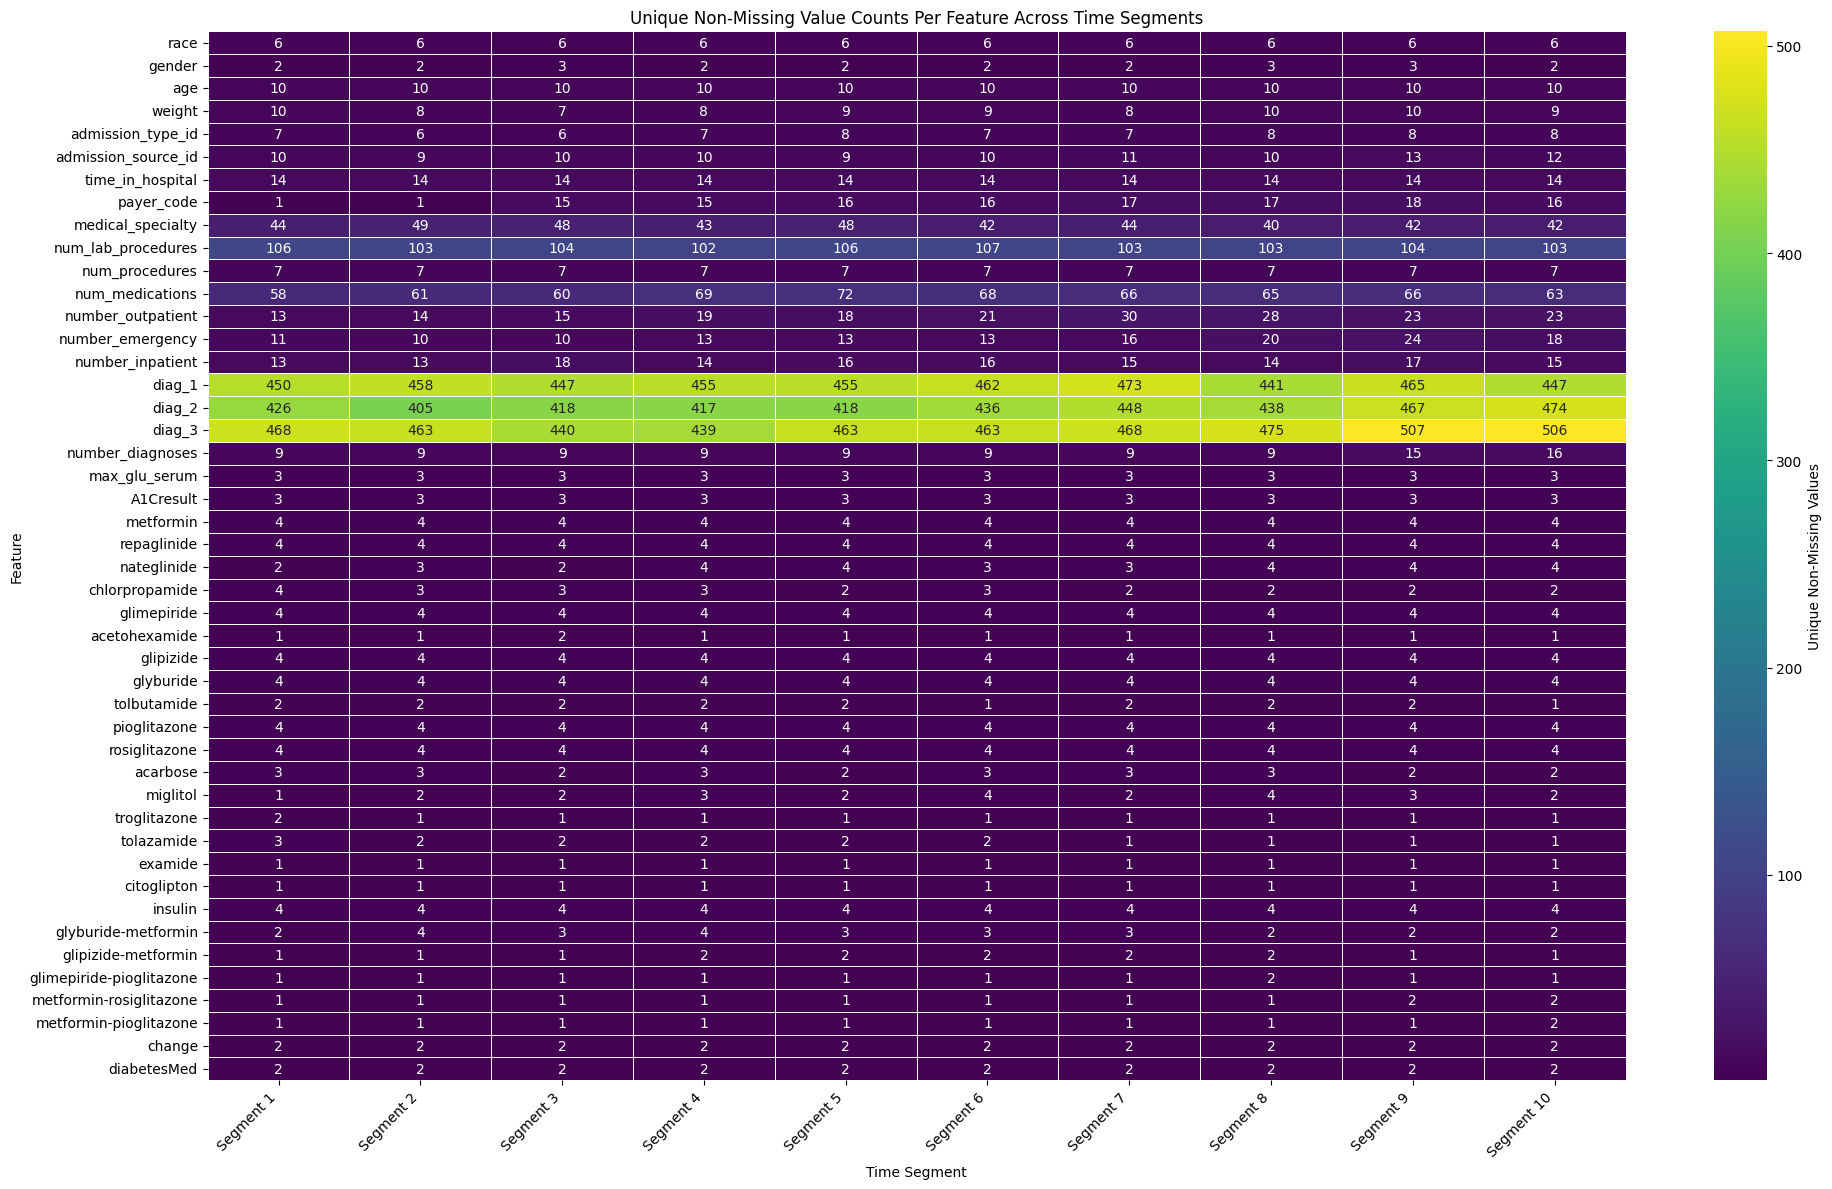

In [ ]:
plt.figure(figsize=(20, 12))
sns.heatmap(unique_counts_per_segment.T, cmap='viridis', annot=True, fmt='d', linewidths=.5, cbar_kws={'label': 'Unique Non-Missing Values'})
plt.title('Unique Non-Missing Value Counts Per Feature Across Time Segments')
plt.xlabel('Time Segment')
plt.ylabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
print("\nSummary of Feature Variability Across Time Segments:")

features_with_changing_variability = []
features_becoming_constant = []
features_becoming_missing = []

for feature in unique_counts_per_segment.columns:
    unique_counts = unique_counts_per_segment[feature]

    # Check for changing variability
    if unique_counts.nunique() > 1: # More than one unique count value across segments
        features_with_changing_variability.append(feature)

    # Check if a feature becomes constant (always 1 unique value) or disappears (always 0 unique values)
    if unique_counts.max() == 1 and unique_counts.min() == 1:
        features_becoming_constant.append(feature)
    elif unique_counts.max() == 0 and unique_counts.min() == 0:
        features_becoming_missing.append(feature)
    # Also check if it starts with >1 unique values and drops to 1 in later segments
    elif unique_counts.iloc[0] > 1 and unique_counts.iloc[-1] == 1 and unique_counts.nunique() > 1:
        features_becoming_constant.append(f"{feature} (becomes constant at 1)")
    # Check for features that might disappear (unique count becomes 0) in later segments
    elif unique_counts.iloc[0] > 0 and unique_counts.iloc[-1] == 0 and unique_counts.nunique() > 1:
        features_becoming_missing.append(f"{feature} (becomes missing)")


print(f"  Features with changing unique value counts across segments: {len(features_with_changing_variability)} features")
if features_with_changing_variability:
    print("    -", ", ".join(features_with_changing_variability))

print(f"  Features that become constant (or are always constant at 1): {len(features_becoming_constant)} features")
if features_becoming_constant:
    print("    -", ", ".join(features_becoming_constant))

print(f"  Features that become missing (or are always missing/empty): {len(features_becoming_missing)} features")
if features_becoming_missing:
    print("    -", ", ".join(features_becoming_missing))




Summary of Feature Variability Across Time Segments:
  Features with changing unique value counts across segments: 28 features
    - gender, weight, admission_type_id, admission_source_id, payer_code, medical_specialty, num_lab_procedures, num_medications, number_outpatient, number_emergency, number_inpatient, diag_1, diag_2, diag_3, number_diagnoses, nateglinide, chlorpropamide, acetohexamide, tolbutamide, acarbose, miglitol, troglitazone, tolazamide, glyburide-metformin, glipizide-metformin, glimepiride-pioglitazone, metformin-rosiglitazone, metformin-pioglitazone
  Features that become constant (or are always constant at 1): 5 features
    - tolbutamide (becomes constant at 1), troglitazone (becomes constant at 1), tolazamide (becomes constant at 1), examide, citoglipton
  Features that become missing (or are always missing/empty): 0 features



Visualizing Features Becoming Constant:


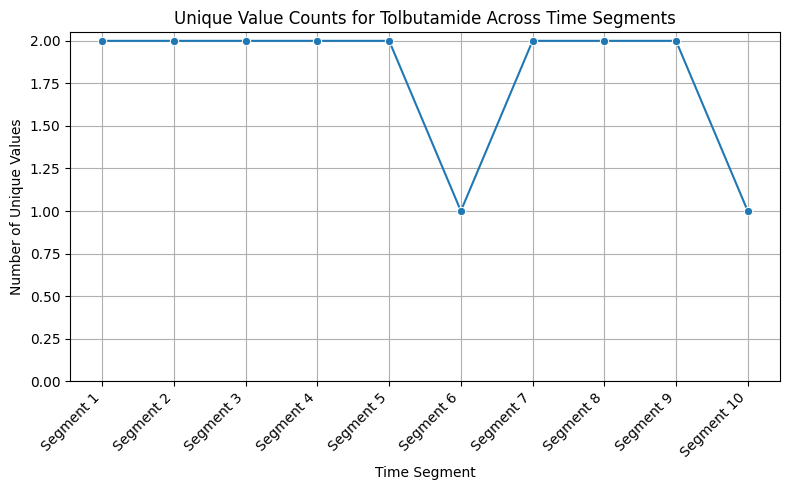

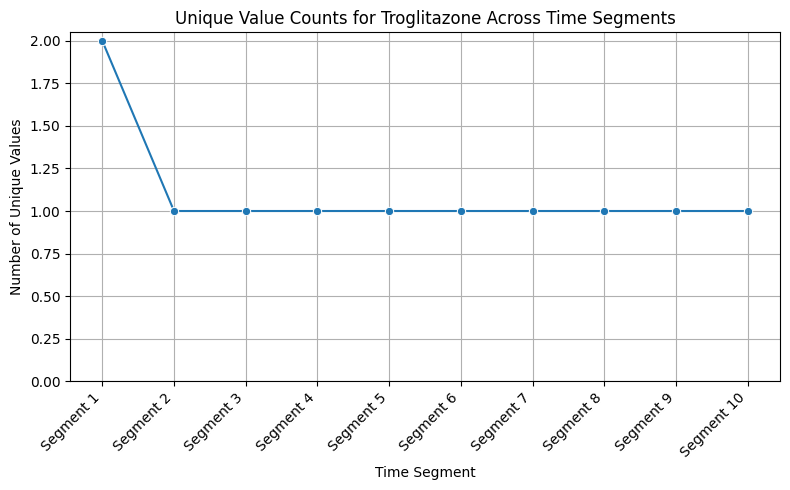

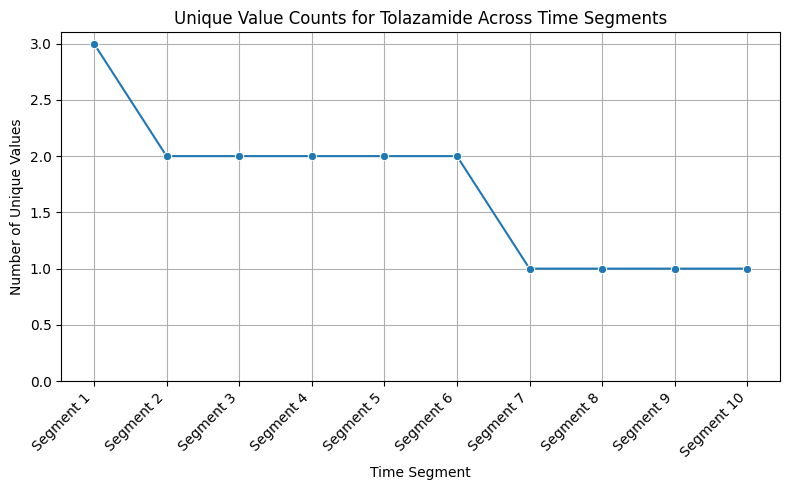

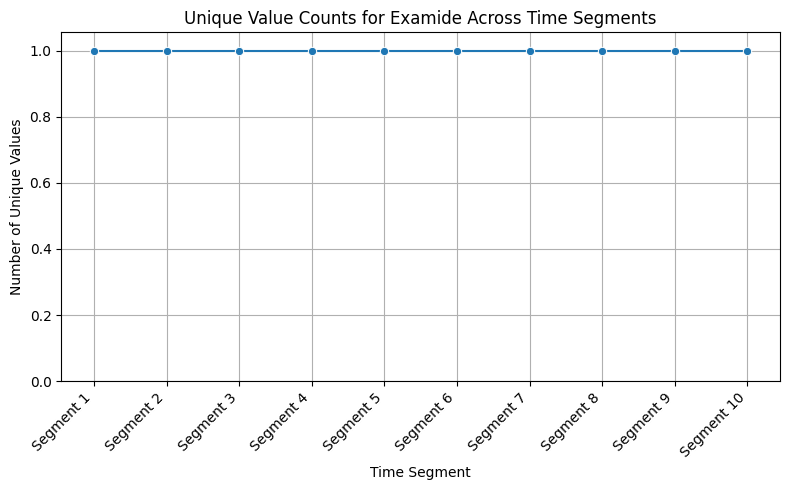

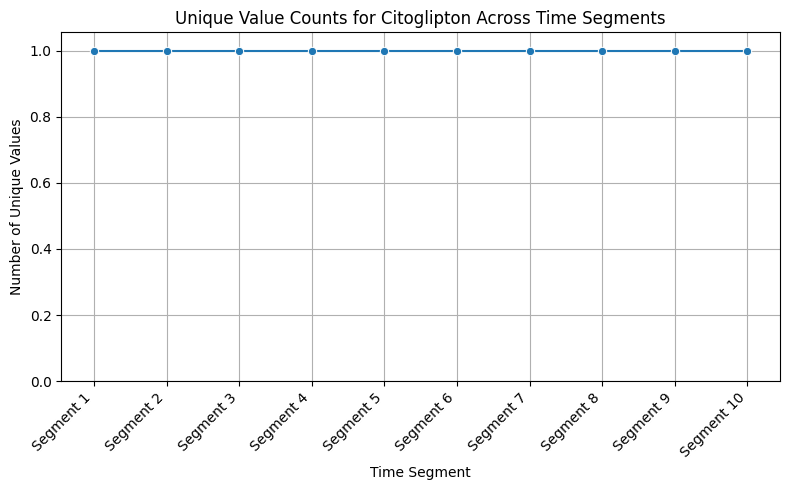

In [ ]:
print("\nVisualizing Features Becoming Constant:")

for feature_info in features_becoming_constant:
    feature_name = feature_info.split(' (becomes constant at 1)')[0]

    # Check if the feature exists in unique_counts_per_segment
    if feature_name in unique_counts_per_segment.columns:
        plt.figure(figsize=(8, 5))
        unique_counts = unique_counts_per_segment[feature_name]
        sns.lineplot(x=unique_counts.index, y=unique_counts.values, marker='o')
        plt.title(f'Unique Value Counts for {feature_name.replace("_", " ").title()} Across Time Segments')
        plt.xlabel('Time Segment')
        plt.ylabel('Number of Unique Values')
        plt.grid(True)
        plt.xticks(rotation=45, ha='right')
        plt.ylim(bottom=0)
        plt.tight_layout()
        plt.show()



#### Remove the features that are not relevant over time

In [ ]:
features_to_drop = ['tolbutamide', 'troglitazone', 'tolazamide', 'examide', 'citoglipton']
categorical_features = [f for f in categorical_features if f not in features_to_drop]

categorical_features = list(dict.fromkeys(categorical_features))

print(categorical_features)


['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'admission_type_id', 'admission_source_id']


### Replace missing values as well as low frequency categories with 'Other'

In [ ]:
for feature in categorical_features:
    df[feature] = df[feature].replace('?', 'Other')
    category_counts = df.groupby(feature)['encounter_id'].nunique()
    low_frequency_categories_to_group = [cat for cat in category_counts.index if category_counts[cat] < 250 and cat != 'Other']

    if len(low_frequency_categories_to_group) > 1:
        df[feature] = df[feature].replace(low_frequency_categories_to_group, 'Other')

### Check for only one unique category per variable and remove the variable

In [ ]:
features_to_remove = []

for feature in categorical_features:
    # Calculate the number of unique 'encounter_id' values for each category
    category_counts = df.groupby(feature)['encounter_id'].nunique()

    # Check if there is only one unique class
    if len(category_counts) == 1:
        features_to_remove.append(feature)
    # Check if there are exactly two unique classes and one has less than 250 customers
    elif len(category_counts) == 2:
        if any(count < 250 for count in category_counts.values):
            features_to_remove.append(feature)

# Remove identified features from the DataFrame
if features_to_remove:
    df = df.drop(columns=features_to_remove)
    print(f"Removed features: {features_to_remove}")
    # Also remove them from the categorical_features list
    categorical_features = [f for f in categorical_features if f not in features_to_remove]
else:
    print("No features met the criteria for removal.")

print("Shape after removing features based on class size criteria:", df.shape)
print("Updated categorical features list:", categorical_features)

Removed features: ['chlorpropamide', 'acetohexamide', 'miglitol', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
Shape after removing features based on class size criteria: (101766, 43)
Updated categorical features list: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'admission_type_id', 'admission_source_id']


In [ ]:
all_features = numeric_features + categorical_features

In [ ]:
y = df['readmitted_30d']
df_features_raw = df.drop(columns=['readmitted_30d'])

# Convert these specific columns to string type in df_features_raw
if 'numeric_colums_categorical' in globals():
    for col in numeric_colums_categorical:
        if col in df_features_raw.columns:
            df_features_raw[col] = df_features_raw[col].astype(str)

# Correctly define all_features to include only actual feature columns
# Exclude identifiers and columns explicitly marked as not features
non_feature_identifiers = ['encounter_id', 'patient_nbr', 'discharge_disposition_id']
all_features = [col for col in df_features_raw.columns if col not in non_feature_identifiers]

df_final_features_sorted = pd.concat([df_features_raw[['encounter_id'] + all_features].reset_index(drop=True),
                                        y.reset_index(drop=True)], axis=1)

df_final_features_sorted = df_final_features_sorted.sort_values("encounter_id").reset_index(drop=True)

display(df_final_features_sorted.head())

,encounter_id,race,gender,age,weight,admission_type_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,acarbose,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,change,diabetesMed,readmitted_30d
0,12522,Caucasian,Female,[80-90),Other,2,4,13,Other,Other,...,No,No,No,No,No,Steady,No,Ch,Yes,0
1,15738,Caucasian,Female,[90-100),Other,3,4,12,Other,InternalMedicine,...,No,No,No,No,No,Steady,No,Ch,Yes,0
2,16680,Caucasian,Male,[40-50),Other,1,7,1,Other,Other,...,No,No,No,No,No,Steady,No,Ch,Yes,0
3,28236,AfricanAmerican,Female,[40-50),Other,1,7,9,Other,Other,...,No,No,No,No,No,Steady,No,No,Yes,0
4,35754,Caucasian,Male,[50-60),Other,2,2,3,Other,Other,...,No,No,No,No,No,Steady,No,No,Yes,0


# Dummy Classifier

### Train Test Split and OHE and Scaler setup

In [ ]:
start_data_point = int(len(df_final_features_sorted) * 0.0001)
# Here played around with only training the model with latest data and testing on latest, for eg start testing at
# group 5/6, but that did not make a big difference on the performance of the model
effective_df = df_final_features_sorted.iloc[start_data_point:].copy()

split_point = int(len(effective_df) * 0.85)

dev_df = effective_df.iloc[:split_point].copy()
test_df = effective_df.iloc[split_point:].copy()

print(f"Shape of dev_df (starting from 50% data mark): {dev_df.shape}")
print(f"Shape of test_df (starting from 50% data mark): {test_df.shape}")


id_cols = ['encounter_id']
target_col = 'readmitted_30d'

X_dev_raw = dev_df.drop(columns=[target_col] + id_cols)
y_dev = dev_df[target_col]

X_test_raw = test_df.drop(columns=[target_col] + id_cols)
y_test = test_df[target_col]

print(f"Shape of X_dev_raw: {X_dev_raw.shape}")
print(f"Shape of y_dev: {y_dev.shape}")
print(f"Shape of X_test_raw: {X_test_raw.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Identify numeric and categorical features for preprocessing
numeric_features_for_preprocessing = X_dev_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features_for_preprocessing = X_dev_raw.select_dtypes(include=['object', 'category']).columns.tolist()

# Create preprocessing pipelines for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_for_preprocessing),
        ('cat', categorical_transformer, categorical_features_for_preprocessing)
    ],
    remainder='passthrough'
)

Shape of dev_df (starting from 50% data mark): (86492, 41)
Shape of test_df (starting from 50% data mark): (15264, 41)
Shape of X_dev_raw: (86492, 39)
Shape of y_dev: (86492,)
Shape of X_test_raw: (15264, 39)
Shape of y_test: (15264,)


## Setup for Walk-Forward CV


In [ ]:
n_splits = 3
pr_auc_scores = []
standard_precision_scores = []
recall_at_precision_08_scores = []
precision_threshold = 0.8

val_window_size = len(dev_df) // (n_splits + 1)

##Apply CV on 3 splits

In [ ]:
print("\n--- Starting Walk-Forward Cross-Validation ---")
for i in range(n_splits):
    print(f"\nFold {i+1}/{n_splits}")


    train_end_idx = (i + 1) * val_window_size

    val_start_idx = train_end_idx
    val_end_idx = val_start_idx + val_window_size


    if val_end_idx > len(dev_df):
        val_end_idx = len(dev_df)


    if val_end_idx <= val_start_idx:
        print(f"Validation window for fold {i+1} is empty or too small, skipping remaining folds.")
        break

    current_train_df_raw = dev_df.iloc[:train_end_idx].copy()
    current_val_df_raw = dev_df.iloc[val_start_idx:val_end_idx].copy()

    X_train_fold_raw = current_train_df_raw.drop(columns=['readmitted_30d', 'encounter_id'])
    y_train_fold = current_train_df_raw['readmitted_30d']
    X_val_fold_raw = current_val_df_raw.drop(columns=['readmitted_30d', 'encounter_id'])
    y_val_fold = current_val_df_raw['readmitted_30d']

    # Clone the preprocessor for each fold to ensure independent fitting and avoid data leakage
    from sklearn.base import clone
    fold_preprocessor = clone(preprocessor)

    X_train_fold_processed = fold_preprocessor.fit_transform(X_train_fold_raw)
    all_feature_names_fold = fold_preprocessor.get_feature_names_out()

    X_val_fold_processed = fold_preprocessor.transform(X_val_fold_raw)

    if hasattr(X_train_fold_processed, 'toarray'):
        X_train_fold_processed = X_train_fold_processed.toarray()
    if hasattr(X_val_fold_processed, 'toarray'):
        X_val_fold_processed = X_val_fold_processed.toarray()

    X_train_fold_processed_df = pd.DataFrame(X_train_fold_processed, columns=all_feature_names_fold)
    X_val_fold_processed_df = pd.DataFrame(X_val_fold_processed, columns=all_feature_names_fold)

    dummy_model = DummyClassifier(strategy='stratified', random_state=42)
    dummy_model.fit(X_train_fold_processed_df, y_train_fold)

    y_val_proba = dummy_model.predict_proba(X_val_fold_processed_df)[:, 1]

    # PR-AUC
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_val_fold, y_val_proba)
    pr_auc = auc(recall_curve, precision_curve)
    pr_auc_scores.append(pr_auc)

    # Precision (from predict())
    y_val_pred = dummy_model.predict(X_val_fold_processed_df)
    current_standard_precision = precision_score(y_val_fold, y_val_pred, zero_division=0)
    standard_precision_scores.append(current_standard_precision)

    # Recall at a fixed precision threshold of 0.8
    high_precision_indices = np.where(precision_curve >= precision_threshold)[0]
    if len(high_precision_indices) > 0:
        best_threshold_idx = high_precision_indices[0]
        recall_at_p_08 = recall_curve[best_threshold_idx]
    else:
        recall_at_p_08 = 0.0
    recall_at_precision_08_scores.append(recall_at_p_08)

    print(f"  PR-AUC: {pr_auc:.4f}")
    print(f"  Precision: {current_standard_precision:.4f}")
    print(f"  Recall (at precision >= {precision_threshold:.1f}): {recall_at_p_08:.4f}")


--- Starting Walk-Forward Cross-Validation ---

Fold 1/3
  PR-AUC: 0.1556
  Precision: 0.1043
  Recall (at precision >= 0.8): 0.0000

Fold 2/3
  PR-AUC: 0.1615
  Precision: 0.1106
  Recall (at precision >= 0.8): 0.0000

Fold 3/3
  PR-AUC: 0.1610
  Precision: 0.1101
  Recall (at precision >= 0.8): 0.0000


#### Average performance of 3 splits

In [ ]:
avg_pr_auc = np.mean(pr_auc_scores)
avg_standard_precision = np.mean(standard_precision_scores)
avg_recall_at_p_08 = np.mean(recall_at_precision_08_scores)

print(f"Average PR-AUC: {avg_pr_auc:.4f}")
print(f"Average Precision: {avg_standard_precision:.4f}")
print(f"Average Recall (at precision >= {precision_threshold:.1f}): {avg_recall_at_p_08:.4f}")

Average PR-AUC: 0.1594
Average Precision: 0.1083
Average Recall (at precision >= 0.8): 0.0000



--- Correlation Matrix of Scaled and OHE Transformed Training Features ---


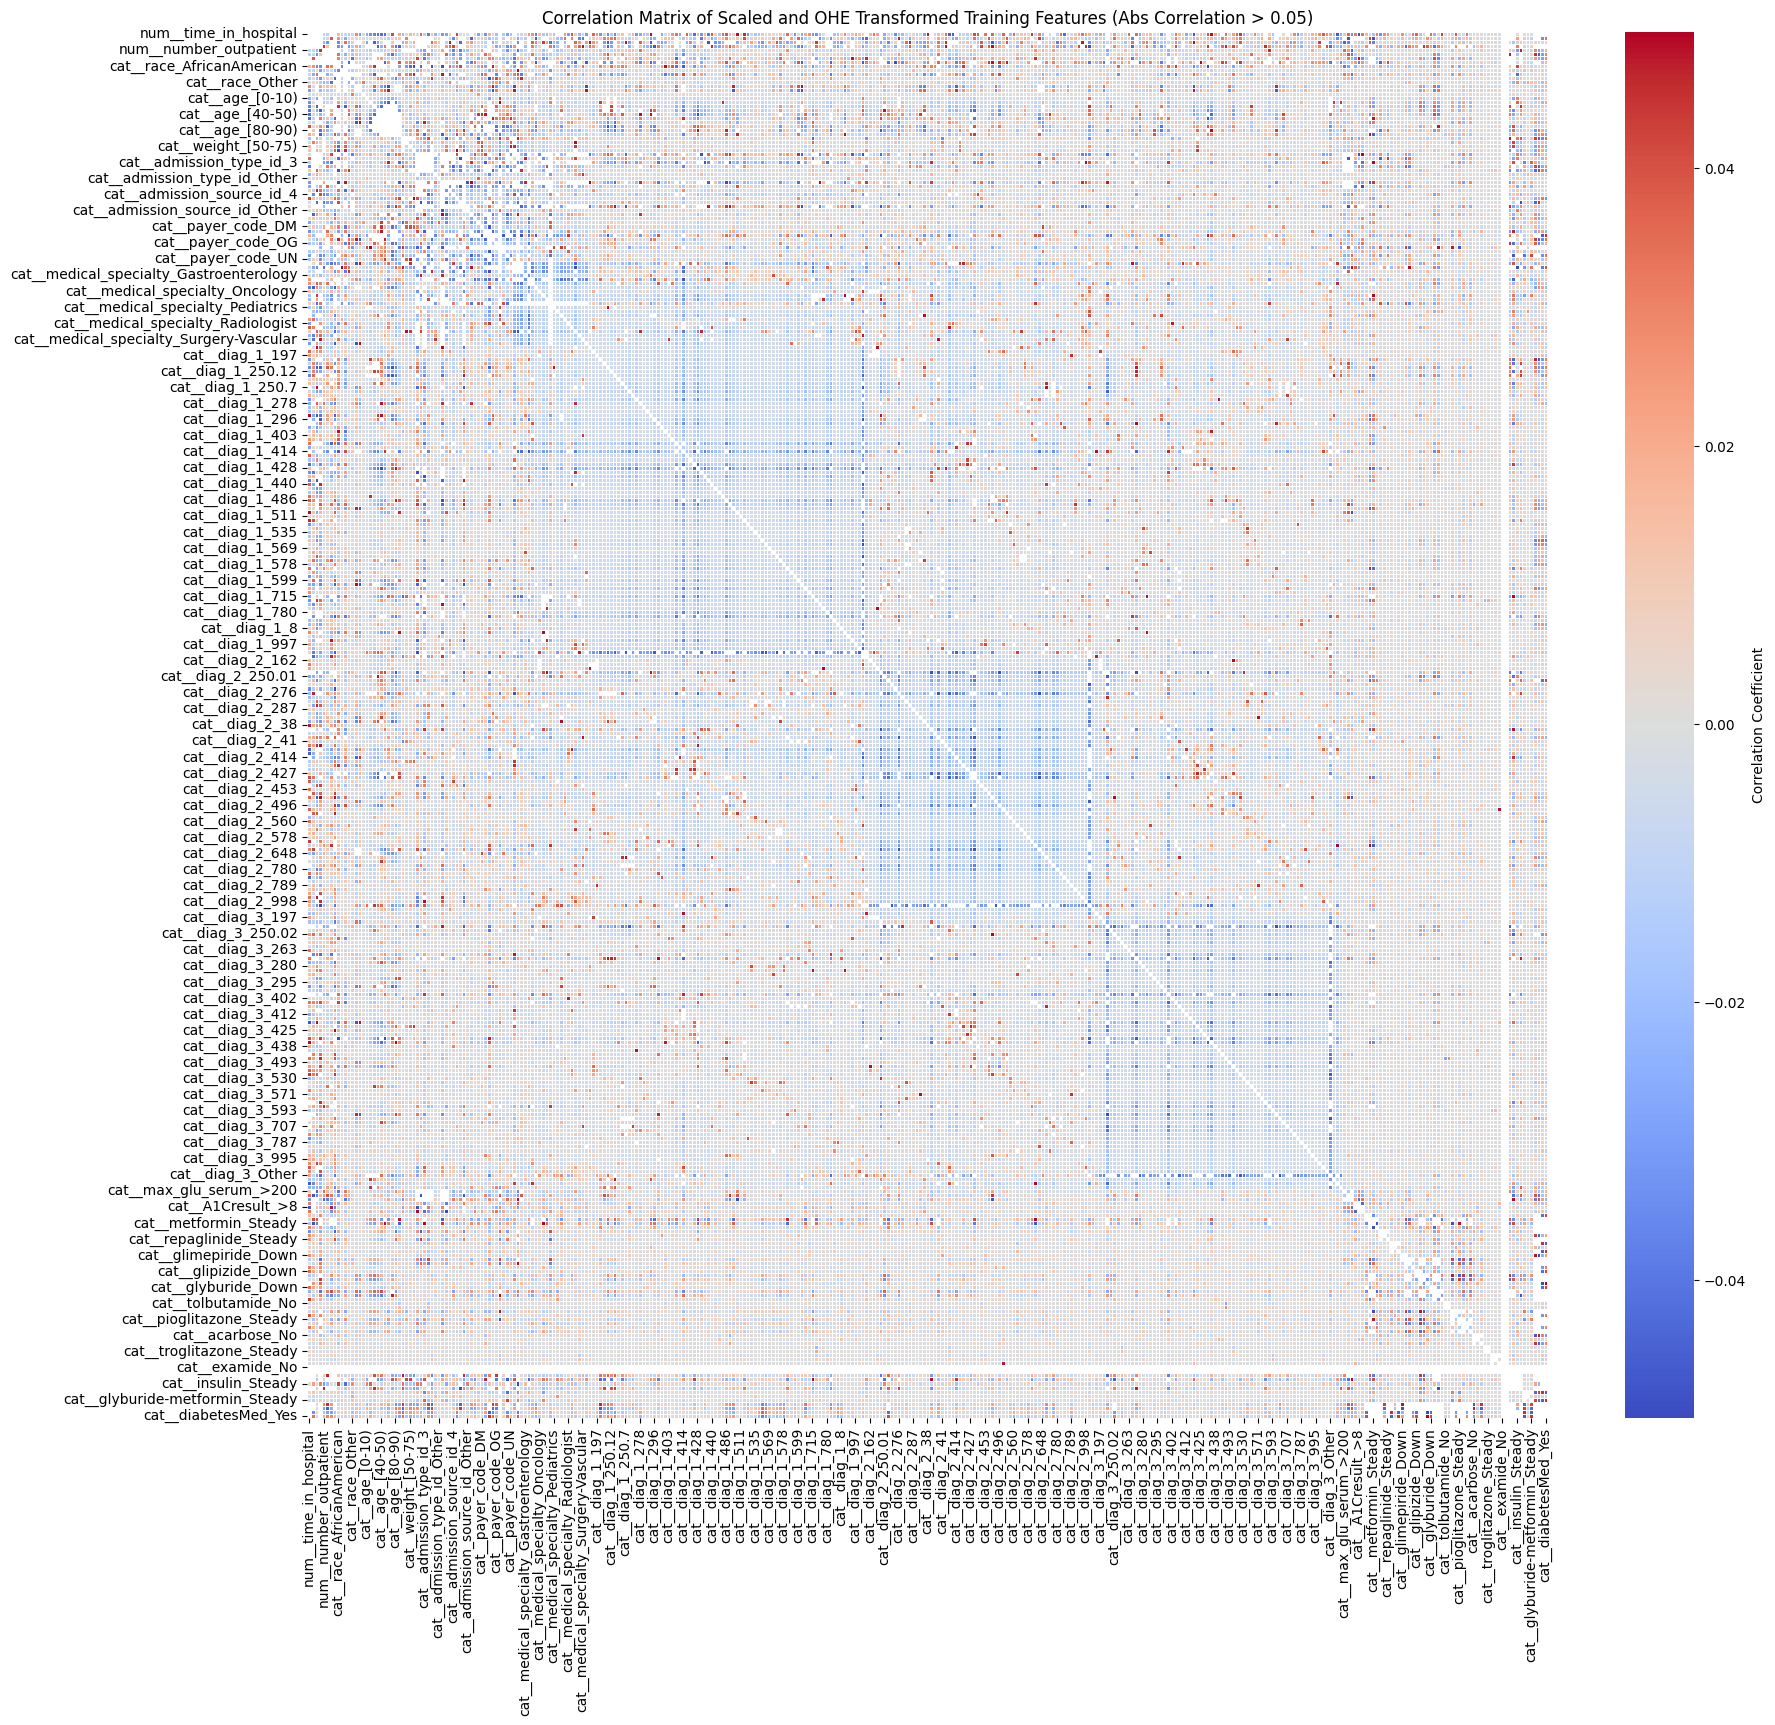

In [ ]:
print("\n--- Correlation Matrix of Scaled and OHE Transformed Training Features ---")

# Clone the preprocessor to avoid altering any already fitted preprocessor
current_preprocessor = clone(preprocessor)
X_dev_processed = current_preprocessor.fit_transform(X_dev_raw)

if hasattr(X_dev_processed, 'toarray'):
    X_dev_processed = X_dev_processed.toarray()

# Get feature names after one-hot encoding for the processed dataframe
all_feature_names_processed = current_preprocessor.get_feature_names_out()

X_dev_processed_df = pd.DataFrame(X_dev_processed, columns=all_feature_names_processed)

correlation_matrix_processed = X_dev_processed_df.corr()

# Mask correlations with absolute value bigger than or equal to 0.05
correlation_matrix_filtered = correlation_matrix_processed.mask(abs(correlation_matrix_processed) >= 0.05)

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix_filtered, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Scaled and OHE Transformed Training Features (Abs Correlation > 0.05)')
plt.show()



##Apply model to train on full Training and Validation datasets and test on Test dataset


--- Retraining on Full Dev Set and Evaluating on Test Set ---
Test Set PR-AUC: 0.1751
Test Set Precision: 0.1260
Test Set Recall (at precision >= 0.8): 0.0000

Test Set Confusion Matrix:
[[12167  1485]
 [ 1398   214]]


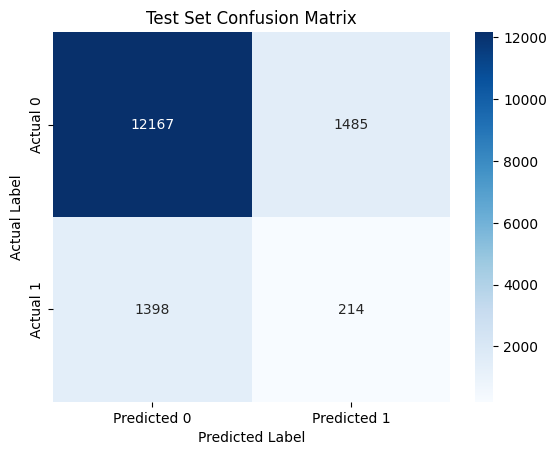

In [ ]:
print("\n--- Retraining on Full Dev Set and Evaluating on Test Set ---")

# Fit preprocessor on the entire dev_df (X_dev_raw)
final_preprocessor = clone(preprocessor)
X_dev_processed = final_preprocessor.fit_transform(X_dev_raw)
X_test_processed = final_preprocessor.transform(X_test_raw)

# Ensure output is dense for DataFrame creation
if hasattr(X_dev_processed, 'toarray'):
    X_dev_processed = X_dev_processed.toarray()
if hasattr(X_test_processed, 'toarray'):
    X_test_processed = X_test_processed.toarray()

# Get feature names after one-hot encoding for the final processed dataframes
all_feature_names_final = final_preprocessor.get_feature_names_out()

X_dev_processed_df = pd.DataFrame(X_dev_processed, columns=all_feature_names_final)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names_final)

# Train final DummyClassifier model on the entire dev_df
final_dummy_model = DummyClassifier(strategy='stratified', random_state=42)
final_dummy_model.fit(X_dev_processed_df, y_dev)

# Predict probabilities and classes on the test set
y_test_proba_final = final_dummy_model.predict_proba(X_test_processed_df)[:, 1]
y_pred_final = final_dummy_model.predict(X_test_processed_df)

# Calculate PR-AUC for the test set
precision_curve_final, recall_curve_final, thresholds_final = precision_recall_curve(y_test, y_test_proba_final)
pr_auc_final = auc(recall_curve_final, precision_curve_final)

# Calculate standard Precision for the test set
test_standard_precision = precision_score(y_test, y_pred_final, zero_division=0)

# Calculate Recall at 0.8 precision for the test set
high_precision_indices_final = np.where(precision_curve_final >= precision_threshold)[0]
if len(high_precision_indices_final) > 0:
    best_threshold_idx_final = high_precision_indices_final[0] # Smallest threshold satisfying precision_threshold
    test_recall_at_p_08 = recall_curve_final[best_threshold_idx_final]
else:
    test_recall_at_p_08 = 0.0000

print(f"Test Set PR-AUC: {pr_auc_final:.4f}")
print(f"Test Set Precision: {test_standard_precision:.4f}")
print(f"Test Set Recall (at precision >= {precision_threshold:.1f}): {test_recall_at_p_08:.4f}")

# Display confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)
print("\nTest Set Confusion Matrix:")
print(cm_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Test Set Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
print("\n--- Summary and Comparison ---")
print("Average Walk-Forward Validation Metrics:")
print(f"  PR-AUC: {avg_pr_auc:.4f}")
print(f"  Precision: {avg_standard_precision:.4f}")
print(f"  Recall (at precision >= {precision_threshold:.1f}): {avg_recall_at_p_08:.4f}")

print("\nFinal Test Set Performance:")
print(f"  PR-AUC: {pr_auc_final:.4f}")
print(f"  Precision: {test_standard_precision:.4f}")
print(f"  Recall (at precision >= {precision_threshold:.1f}): {test_recall_at_p_08:.4f}")



--- Summary and Comparison ---
Average Walk-Forward Validation Metrics:
  PR-AUC: 0.1594
  Precision: 0.1083
  Recall (at precision >= 0.8): 0.0000

Final Test Set Performance:
  PR-AUC: 0.1751
  Precision: 0.1260
  Recall (at precision >= 0.8): 0.0000


# SGDClassifier


In [ ]:
eta0_scenarios = [1e-4, 1e-3, 1e-2]
n_epochs = 20
tol = 1e-3
loss = 'log_loss'

metrics_by_eta0 = {
    eta0: {
        'train_pr_auc_histories': [],
        'val_pr_auc_histories': [],
        'val_accuracy_histories': [],
        'val_f1_histories': [],
        'val_recall_at_p_08_histories': [],
        'val_precision_histories': [],
        'training_times': []
    } for eta0 in eta0_scenarios
}

In [ ]:
print("\n--- Starting Walk-Forward Cross-Validation for SGDClassifier (with epoch tracking) ---")

for eta0 in eta0_scenarios:
    print(f"\n--- Current eta0: {eta0} ---")
    for i in range(n_splits):
        print(f"  Fold {i+1}/{n_splits}")

        # Define expanding training block and subsequent fixed-size validation block
        train_end_idx = (i + 1) * val_window_size
        val_start_idx = train_end_idx
        val_end_idx = val_start_idx + val_window_size

        if val_end_idx > len(dev_df):
            val_end_idx = len(dev_df)

        if val_end_idx <= val_start_idx:
            print(f"  Validation window for fold {i+1} is empty or too small, skipping remaining folds for eta0 {eta0}.")
            break

        current_train_df_raw = dev_df.iloc[:train_end_idx].copy()
        current_val_df_raw = dev_df.iloc[val_start_idx:val_end_idx].copy()

        X_train_fold_raw = current_train_df_raw.drop(columns=['readmitted_30d', 'encounter_id'])
        y_train_fold = current_train_df_raw['readmitted_30d']
        X_val_fold_raw = current_val_df_raw.drop(columns=['readmitted_30d', 'encounter_id'])
        y_val_fold = current_val_df_raw['readmitted_30d']

        fold_preprocessor = clone(preprocessor)
        X_train_fold_processed = fold_preprocessor.fit_transform(X_train_fold_raw)
        all_feature_names_fold = fold_preprocessor.get_feature_names_out()
        X_val_fold_processed = fold_preprocessor.transform(X_val_fold_raw)

        if hasattr(X_train_fold_processed, 'toarray'):
            X_train_fold_processed = X_train_fold_processed.toarray()
        if hasattr(X_val_fold_processed, 'toarray'):
            X_val_fold_processed = X_val_fold_processed.toarray()

        X_train_fold_processed_df = pd.DataFrame(X_train_fold_processed, columns=all_feature_names_fold)
        X_val_fold_processed_df = pd.DataFrame(X_val_fold_processed, columns=all_feature_names_fold)

        # Compute class weights for the current training fold
        class_weights = compute_class_weight('balanced', classes=np.unique(y_train_fold), y=y_train_fold)
        class_weight_dict = {cls: weight for cls, weight in zip(np.unique(y_train_fold), class_weights)}

        # Initialize SGDClassifier for partial_fit
        sgd_model = SGDClassifier(loss=loss,
                                  eta0=eta0,
                                  max_iter=1,
                                  tol=tol,
                                  class_weight=class_weight_dict,
                                  learning_rate='constant',
                                  random_state=101,
                                  fit_intercept=True,
                                  warm_start=True
                                  )

        # Lists to store metrics for each epoch within this fold
        current_fold_train_pr_auc_hist = []
        current_fold_val_pr_auc_hist = []
        current_fold_val_accuracy_hist = []
        current_fold_val_f1_hist = []
        current_fold_val_recall_at_p_08_hist = []
        current_fold_val_precision_hist = []

        start_time_fold = time.time() # Start time for the entire fold training

        for epoch in range(n_epochs):

            # Need to specify classes for partial_fit if not all classes are present in initial batches
            sgd_model.partial_fit(X_train_fold_processed_df, y_train_fold, classes=np.unique(y_train_fold))

            # Calculate metrics for this epoch
            if len(np.unique(y_train_fold)) > 1:
                y_train_proba_epoch = sgd_model.predict_proba(X_train_fold_processed_df)[:, 1] # Predict on original data
                pr_auc_train_epoch = average_precision_score(y_train_fold, y_train_proba_epoch) # Use original target
                current_fold_train_pr_auc_hist.append(pr_auc_train_epoch)
            else:
                current_fold_train_pr_auc_hist.append(np.nan)


            if len(np.unique(y_val_fold)) > 1: # Only calculate if val_fold has more than one class
                y_val_proba_epoch = sgd_model.predict_proba(X_val_fold_processed_df)[:, 1]
                pr_auc_val_epoch = average_precision_score(y_val_fold, y_val_proba_epoch)
                current_fold_val_pr_auc_hist.append(pr_auc_val_epoch)

                y_val_pred_epoch = sgd_model.predict(X_val_fold_processed_df)
                val_accuracy_epoch = accuracy_score(y_val_fold, y_val_pred_epoch)
                val_f1_epoch = f1_score(y_val_fold, y_val_pred_epoch, zero_division=0)
                val_precision_epoch = precision_score(y_val_fold, y_val_pred_epoch, zero_division=0)

                current_fold_val_accuracy_hist.append(val_accuracy_epoch)
                current_fold_val_f1_hist.append(val_f1_epoch)
                current_fold_val_precision_hist.append(val_precision_epoch)

                precision_curve_val, recall_curve_val, _ = precision_recall_curve(y_val_fold, y_val_proba_epoch)
                high_precision_indices_val = np.where(precision_curve_val >= precision_threshold)[0]
                if len(high_precision_indices_val) > 0:
                    recall_at_p_08_val_epoch = recall_curve_val[high_precision_indices_val[0]]
                else:
                    recall_at_p_08_val_epoch = 0.0000
                current_fold_val_recall_at_p_08_hist.append(recall_at_p_08_val_epoch)
            else:
                current_fold_val_pr_auc_hist.append(np.nan)
                current_fold_val_accuracy_hist.append(np.nan)
                current_fold_val_f1_hist.append(np.nan)
                current_fold_val_precision_hist.append(np.nan)
                current_fold_val_recall_at_p_08_hist.append(np.nan)

        end_time_fold = time.time()
        training_duration_fold = end_time_fold - start_time_fold

        # Store the history for this fold
        metrics_by_eta0[eta0]['train_pr_auc_histories'].append(current_fold_train_pr_auc_hist)
        metrics_by_eta0[eta0]['val_pr_auc_histories'].append(current_fold_val_pr_auc_hist)
        metrics_by_eta0[eta0]['val_accuracy_histories'].append(current_fold_val_accuracy_hist)
        metrics_by_eta0[eta0]['val_f1_histories'].append(current_fold_val_f1_hist)
        metrics_by_eta0[eta0]['val_recall_at_p_08_histories'].append(current_fold_val_recall_at_p_08_hist)
        metrics_by_eta0[eta0]['val_precision_histories'].append(current_fold_val_precision_hist)
        metrics_by_eta0[eta0]['training_times'].append(training_duration_fold)

        # Print final epoch metrics for clarity during execution
        print(f"    Train PR-AUC (last epoch): {current_fold_train_pr_auc_hist[-1]:.4f}")
        print(f"    Validation PR-AUC (last epoch): {current_fold_val_pr_auc_hist[-1]:.4f}")
        print(f"    Validation Accuracy (last epoch): {current_fold_val_accuracy_hist[-1]:.4f}")
        print(f"    Validation F1-score (last epoch): {current_fold_val_f1_hist[-1]:.4f}")
        print(f"    Validation Precision (last epoch): {current_fold_val_precision_hist[-1]:.4f}")
        print(f"    Validation Recall (at precision >= {precision_threshold:.1f}, last epoch): {current_fold_val_recall_at_p_08_hist[-1]:.4f}")

print("\n--- Walk-Forward Cross-Validation for SGDClassifier Complete (with epoch tracking) ---")


--- Starting Walk-Forward Cross-Validation for SGDClassifier (with epoch tracking) ---

--- Current eta0: 0.0001 ---
  Fold 1/3
    Train PR-AUC (last epoch): 0.1981
    Validation PR-AUC (last epoch): 0.2075
    Validation Accuracy (last epoch): 0.5594
    Validation F1-score (last epoch): 0.2566
    Validation Precision (last epoch): 0.1586
    Validation Recall (at precision >= 0.8, last epoch): 0.0000
  Fold 2/3
    Train PR-AUC (last epoch): 0.2069
    Validation PR-AUC (last epoch): 0.1889
    Validation Accuracy (last epoch): 0.5246
    Validation F1-score (last epoch): 0.2448
    Validation Precision (last epoch): 0.1492
    Validation Recall (at precision >= 0.8, last epoch): 0.0000
  Fold 3/3
    Train PR-AUC (last epoch): 0.2030
    Validation PR-AUC (last epoch): 0.1987
    Validation Accuracy (last epoch): 0.5930
    Validation F1-score (last epoch): 0.2455
    Validation Precision (last epoch): 0.1539
    Validation Recall (at precision >= 0.8, last epoch): 0.0000

--- C

In [ ]:
print("\n--- Average Metrics for Each eta0 Scenario (SGDClassifier) ---")

for eta0, metrics in metrics_by_eta0.items():
    # Extract last epoch's metrics from each fold's history list
    last_epoch_train_pr_aucs = [hist[-1] for hist in metrics['train_pr_auc_histories'] if hist]
    last_epoch_val_pr_aucs = [hist[-1] for hist in metrics['val_pr_auc_histories'] if hist]
    last_epoch_val_accuracies = [hist[-1] for hist in metrics['val_accuracy_histories'] if hist]
    last_epoch_val_f1s = [hist[-1] for hist in metrics['val_f1_histories'] if hist]
    last_epoch_val_recall_at_p_08s = [hist[-1] for hist in metrics['val_recall_at_p_08_histories'] if hist]
    last_epoch_val_precisions = [hist[-1] for hist in metrics['val_precision_histories'] if hist]

    avg_train_pr_auc = np.mean(last_epoch_train_pr_aucs)
    avg_val_pr_auc = np.mean(last_epoch_val_pr_aucs)
    avg_val_accuracy = np.mean(last_epoch_val_accuracies)
    avg_val_f1 = np.mean(last_epoch_val_f1s)
    avg_val_recall_at_p_08 = np.mean(last_epoch_val_recall_at_p_08s)
    avg_val_precision = np.mean(last_epoch_val_precisions)
    avg_training_time = np.mean(metrics['training_times'])

    print(f"\neta0 = {eta0}:")
    print(f"  Average Train PR-AUC (last epoch): {avg_train_pr_auc:.4f}")
    print(f"  Average Validation PR-AUC (last epoch): {avg_val_pr_auc:.4f}")
    print(f"  Average Validation Accuracy (last epoch): {avg_val_accuracy:.4f}")
    print(f"  Average Validation F1-score (last epoch): {avg_val_f1:.4f}")
    print(f"  Average Validation Precision (last epoch): {avg_val_precision:.4f}")
    print(f"  Average Validation Recall (at precision >= {precision_threshold:.1f}, last epoch): {avg_val_recall_at_p_08:.4f}")
    print(f"  Average Training Time (total per fold): {avg_training_time:.4f} seconds")


--- Average Metrics for Each eta0 Scenario (SGDClassifier) ---

eta0 = 0.0001:
  Average Train PR-AUC (last epoch): 0.2027
  Average Validation PR-AUC (last epoch): 0.1984
  Average Validation Accuracy (last epoch): 0.5590
  Average Validation F1-score (last epoch): 0.2490
  Average Validation Precision (last epoch): 0.1539
  Average Validation Recall (at precision >= 0.8, last epoch): 0.0000
  Average Training Time (total per fold): 3.3329 seconds

eta0 = 0.001:
  Average Train PR-AUC (last epoch): 0.2116
  Average Validation PR-AUC (last epoch): 0.1969
  Average Validation Accuracy (last epoch): 0.5003
  Average Validation F1-score (last epoch): 0.2419
  Average Validation Precision (last epoch): 0.1457
  Average Validation Recall (at precision >= 0.8, last epoch): 0.0000
  Average Training Time (total per fold): 3.3600 seconds

eta0 = 0.01:
  Average Train PR-AUC (last epoch): 0.1997
  Average Validation PR-AUC (last epoch): 0.1874
  Average Validation Accuracy (last epoch): 0.5273

Best eta0 determined from cross-validation (based on last epoch's metrics): 0.0001

--- Retraining Best SGDClassifier on Full Dev Set and Evaluating on Test Set (with epoch tracking) ---
Final SGDClassifier training time (for 20 epochs): 3.0128 seconds
Test Set PR-AUC (SGDClassifier): 0.1932
Test Set Accuracy (SGDClassifier): 0.6594
Test Set F1-score (SGDClassifier): 0.2402
Test Set Precision (SGDClassifier): 0.1571
Test Set Recall (at precision >= 0.8) (SGDClassifier): 0.0000

Test Set Confusion Matrix (SGDClassifier):
[[9243 4409]
 [ 790  822]]


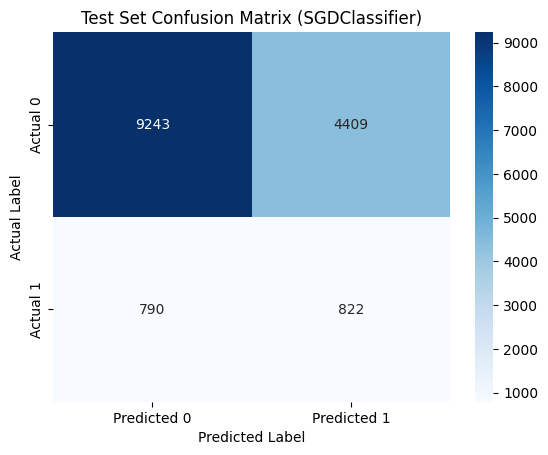

In [ ]:
best_eta0 = None
best_pr_auc = -1
best_training_time = float('inf')

for eta0, metrics in metrics_by_eta0.items():
    # Use last epoch's average validation PR-AUC for comparison
    if metrics['val_pr_auc_histories'] and metrics['val_pr_auc_histories'][0]:
        avg_val_pr_auc = np.mean([hist[-1] for hist in metrics['val_pr_auc_histories']])
    else:
        avg_val_pr_auc = -1 # Set to -1 or similar if no valid scores

    avg_training_time = np.mean(metrics['training_times'])

    if avg_val_pr_auc > best_pr_auc:
        best_pr_auc = avg_val_pr_auc
        best_training_time = avg_training_time
        best_eta0 = eta0
    elif avg_val_pr_auc == best_pr_auc:
        if avg_training_time < best_training_time:
            best_training_time = avg_training_time
            best_eta0 = eta0

print(f"Best eta0 determined from cross-validation (based on last epoch's metrics): {best_eta0}")

print("\n--- Retraining Best SGDClassifier on Full Dev Set and Evaluating on Test Set (with epoch tracking) ---")

# Clone the preprocessor for the final model
final_preprocessor = clone(preprocessor)

# Fit preprocessor on the entire dev_df (X_dev_raw)
X_dev_processed = final_preprocessor.fit_transform(X_dev_raw)
X_test_processed = final_preprocessor.transform(X_test_raw)

# Ensure output is dense for DataFrame creation
if hasattr(X_dev_processed, 'toarray'):
    X_dev_processed = X_dev_processed.toarray()
if hasattr(X_test_processed, 'toarray'):
    X_test_processed = X_test_processed.toarray()

# Get feature names after one-hot encoding for the final processed dataframes
all_feature_names_final = final_preprocessor.get_feature_names_out()

X_dev_processed_df = pd.DataFrame(X_dev_processed, columns=all_feature_names_final)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names_final)

# Calculate class weights for the full y_dev dataset
class_weights_final = compute_class_weight('balanced', classes=np.unique(y_dev), y=y_dev)
class_weight_dict_final = {cls: weight for cls, weight in zip(np.unique(y_dev), class_weights_final)}

# Initialize and train SGDClassifier with the best eta0 for partial_fit
final_sgd_model = SGDClassifier(loss=loss, eta0=best_eta0, max_iter=1, tol=tol,
                                  random_state=42, class_weight=class_weight_dict_final,
                                  learning_rate='constant',
                                  fit_intercept=True,
                                  warm_start=True
                                  )

final_model_train_start_time = time.time()
for epoch in range(n_epochs): # Train for n_epochs
    final_sgd_model.partial_fit(X_dev_processed_df, y_dev, classes=np.unique(y_dev))
final_model_train_end_time = time.time()
training_duration_final = final_model_train_end_time - final_model_train_start_time

print(f"Final SGDClassifier training time (for {n_epochs} epochs): {training_duration_final:.4f} seconds")

# Predict probabilities and class labels on the test set (after all epochs)
y_test_proba_sgd = final_sgd_model.predict_proba(X_test_processed_df)[:, 1]
y_pred_sgd = final_sgd_model.predict(X_test_processed_df)

# Calculate PR-AUC for the test set
precision_curve_sgd, recall_curve_sgd, thresholds_sgd = precision_recall_curve(y_test, y_test_proba_sgd)
pr_auc_sgd = average_precision_score(y_test, y_test_proba_sgd)

# Calculate Accuracy, F1-score, and Precision for the test set
test_accuracy_sgd = accuracy_score(y_test, y_pred_sgd)
test_f1_sgd = f1_score(y_test, y_pred_sgd, zero_division=0)
test_precision_sgd = precision_score(y_test, y_pred_sgd, zero_division=0)

# Calculate Recall at a fixed precision threshold of 0.8 for the test set
high_precision_indices_sgd = np.where(precision_curve_sgd >= precision_threshold)[0]
if len(high_precision_indices_sgd) > 0:
    test_recall_at_p_08_sgd = recall_curve_sgd[high_precision_indices_sgd[0]]
else:
    test_recall_at_p_08_sgd = 0.0

print(f"Test Set PR-AUC (SGDClassifier): {pr_auc_sgd:.4f}")
print(f"Test Set Accuracy (SGDClassifier): {test_accuracy_sgd:.4f}")
print(f"Test Set F1-score (SGDClassifier): {test_f1_sgd:.4f}")
print(f"Test Set Precision (SGDClassifier): {test_precision_sgd:.4f}")
print(f"Test Set Recall (at precision >= {precision_threshold:.1f}) (SGDClassifier): {test_recall_at_p_08_sgd:.4f}")

# Display confusion matrix
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
print("\nTest Set Confusion Matrix (SGDClassifier):")
print(cm_sgd)
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Test Set Confusion Matrix (SGDClassifier)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:

print("\n--- Evaluating All Manual eta0 Models on Test Set ---")

# Initialize an empty dictionary to store test performance metrics for each eta0 scenario
test_metrics_by_eta0_scenario = {}

for eta0_val in eta0_scenarios:
    print(f"\nEvaluating eta0: {eta0_val}")

    # Initialize SGDClassifier with specified parameters
    current_sgd_model = SGDClassifier(
        loss=loss,
        eta0=eta0_val,
        penalty='l2',
        alpha=0.0001,
        class_weight=class_weight_dict_final,
        learning_rate='constant',
        random_state=42,
        fit_intercept=True,
        warm_start=True,
        max_iter=1
    )

    start_time = time.time()

    # Train the current SGD model using partial_fit for n_epochs iterations on the full dev set
    for epoch in range(n_epochs):
        current_sgd_model.partial_fit(X_dev_processed_df, y_dev, classes=np.unique(y_dev))

    end_time = time.time()
    training_duration = end_time - start_time

    # Predict probabilities for the positive class on the test set
    y_test_proba_sgd = current_sgd_model.predict_proba(X_test_processed_df)[:, 1]

    # Predict class labels on the test set
    y_pred_sgd = current_sgd_model.predict(X_test_processed_df)

    # Calculate PR-AUC for the test set
    pr_auc_test = average_precision_score(y_test, y_test_proba_sgd)

    # Calculate Precision for the test set
    precision_test = precision_score(y_test, y_pred_sgd, zero_division=0)

    # Calculate Recall at a fixed precision threshold of 0.8 for the test set
    precision_curve_test, recall_curve_test, _ = precision_recall_curve(y_test, y_test_proba_sgd)
    high_precision_indices_test = np.where(precision_curve_test >= precision_threshold)[0]
    if len(high_precision_indices_test) > 0:
        recall_at_p_08_test = recall_curve_test[high_precision_indices_test[0]]
    else:
        recall_at_p_08_test = 0.0

    # Store the calculated metrics in the dictionary
    test_metrics_by_eta0_scenario[eta0_val] = {
        'pr_auc': pr_auc_test,
        'precision': precision_test,
        'recall_at_p_08': recall_at_p_08_test,
        'training_time': training_duration
    }

    # Print the test set metrics for the current eta0_val
    print(f"  Test Set PR-AUC: {pr_auc_test:.4f}")
    print(f"  Test Set Precision: {precision_test:.4f}")
    print(f"  Test Set Recall (at precision >= {precision_threshold:.1f}): {recall_at_p_08_test:.4f}")
    print(f"  Training Time: {training_duration:.4f} seconds")

print("\nEvaluation for all eta0 scenarios complete.")


--- Evaluating All Manual eta0 Models on Test Set ---

Evaluating eta0: 0.0001
  Test Set PR-AUC: 0.1932
  Test Set Precision: 0.1571
  Test Set Recall (at precision >= 0.8): 0.0000
  Training Time: 3.0042 seconds

Evaluating eta0: 0.001
  Test Set PR-AUC: 0.1876
  Test Set Precision: 0.1548
  Test Set Recall (at precision >= 0.8): 0.0000
  Training Time: 3.0273 seconds

Evaluating eta0: 0.01
  Test Set PR-AUC: 0.1739
  Test Set Precision: 0.1987
  Test Set Recall (at precision >= 0.8): 0.0000
  Training Time: 3.0413 seconds

Evaluation for all eta0 scenarios complete.


In [ ]:
# Initialize a list to store data for the table
table_data = []

for eta0, metrics in metrics_by_eta0.items():
    # Extract last epoch's metrics from each fold's history list for validation scores
    last_epoch_train_pr_aucs = [hist[-1] for hist in metrics['train_pr_auc_histories'] if hist]
    last_epoch_val_pr_aucs = [hist[-1] for hist in metrics['val_pr_auc_histories'] if hist]
    last_epoch_val_recall_at_p_08s = [hist[-1] for hist in metrics['val_recall_at_p_08_histories'] if hist]
    last_epoch_val_precisions = [hist[-1] for hist in metrics['val_precision_histories'] if hist]

    # Calculate averages for validation metrics
    avg_train_pr_auc = np.mean(last_epoch_train_pr_aucs) if last_epoch_train_pr_aucs else np.nan
    avg_val_pr_auc = np.mean(last_epoch_val_pr_aucs) if last_epoch_val_pr_aucs else np.nan
    avg_val_recall_at_p_08 = np.mean(last_epoch_val_recall_at_p_08s) if last_epoch_val_recall_at_p_08s else np.nan
    avg_val_precision = np.mean(last_epoch_val_precisions) if last_epoch_val_precisions else np.nan

    # Retrieve test metrics for the current eta0 from test_metrics_by_eta0_scenario
    test_metrics = test_metrics_by_eta0_scenario.get(eta0, {})
    test_pr_auc = test_metrics.get('pr_auc', np.nan)
    test_precision = test_metrics.get('precision', np.nan)
    test_recall_at_p_08 = test_metrics.get('recall_at_p_08', np.nan)
    test_training_time = test_metrics.get('training_time', np.nan)

    table_data.append({
        'LR (eta0)': eta0,
        'Train PR-AUC': avg_train_pr_auc,
        'Val PR-AUC': avg_val_pr_auc,
        'Test PR-AUC': test_pr_auc,
        'Val Rec@P>=0.8': avg_val_recall_at_p_08,
        'Test Rec@P>=0.8': test_recall_at_p_08,
        'Val Precision': avg_val_precision,
        'Test Precision': test_precision,
        'Test Train Time (s)': test_training_time
    })

# Create DataFrame and display
metrics_df = pd.DataFrame(table_data)

print("\n--- SGDClassifier Performance Metrics by eta0 Scenario (Validation & Test) ---")
display(metrics_df.round(4))




--- SGDClassifier Performance Metrics by eta0 Scenario (Validation & Test) ---


,LR (eta0),Train PR-AUC,Val PR-AUC,Test PR-AUC,Val Rec@P>=0.8,Test Rec@P>=0.8,Val Precision,Test Precision,Test Train Time (s)
0,0.0001,0.2027,0.1984,0.1932,0.0000,0.0,0.1539,0.1571,3.0042
1,0.0010,0.2116,0.1969,0.1876,0.0000,0.0,0.1457,0.1548,3.0273
2,0.0100,0.1997,0.1874,0.1739,0.0001,0.0,0.1440,0.1987,3.0413



--- Plotting PR-AUC Epoch Histories for Each eta0 Scenario (Side-by-Side) with Test Results ---


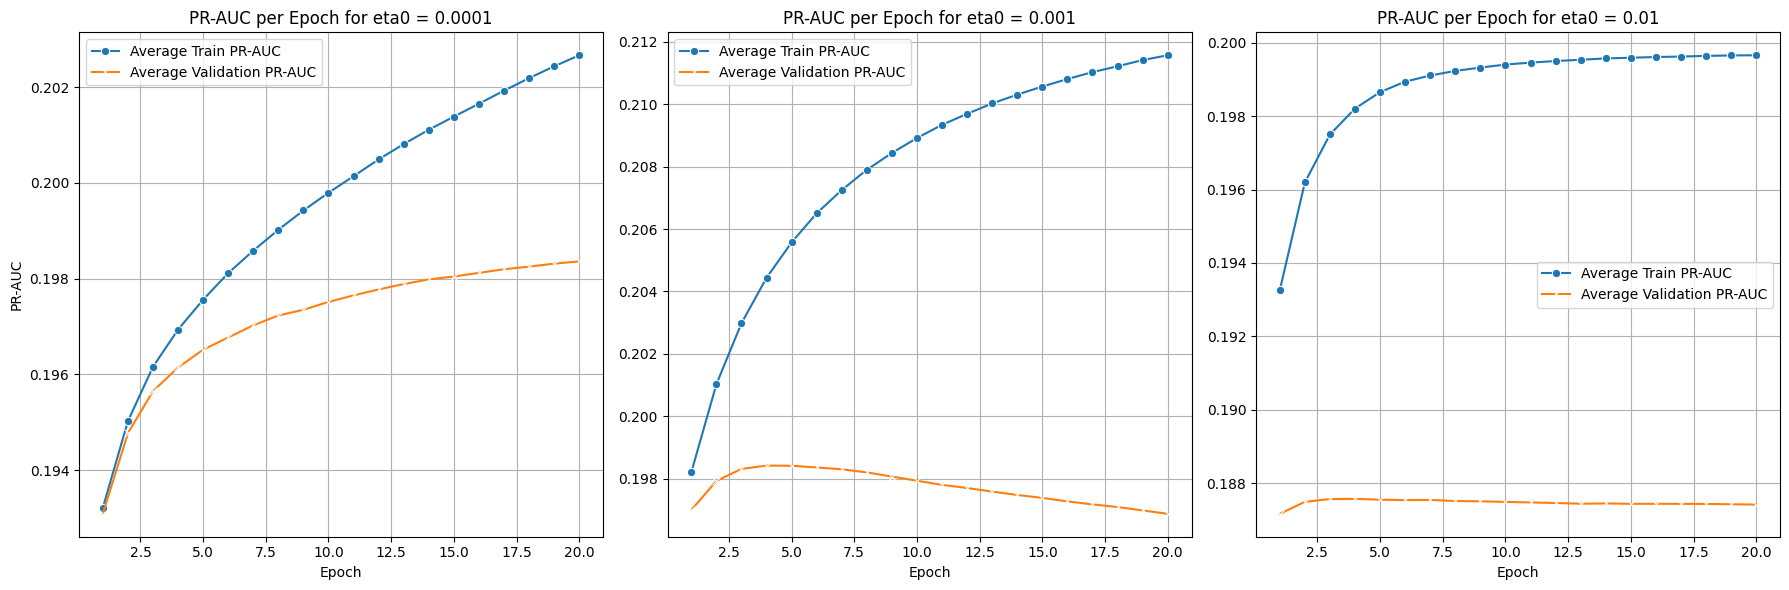


--- PR-AUC Epoch Histories Plots Complete ---


In [ ]:


print("\n--- Plotting PR-AUC Epoch Histories for Each eta0 Scenario (Side-by-Side) with Test Results ---")

# Create a single figure with subplots for each eta0 scenario
fig, axes = plt.subplots(1, len(eta0_scenarios), figsize=(6 * len(eta0_scenarios), 6), sharey=False)

if len(eta0_scenarios) == 1:
    axes = [axes]

for idx, eta0 in enumerate(eta0_scenarios):
    ax = axes[idx]
    metrics = metrics_by_eta0[eta0]

    if metrics['train_pr_auc_histories']:
        avg_train_pr_auc_per_epoch = np.mean(metrics['train_pr_auc_histories'], axis=0)
    else:
        avg_train_pr_auc_per_epoch = np.array([])

    if metrics['val_pr_auc_histories']:
        avg_val_pr_auc_per_epoch = np.mean(metrics['val_pr_auc_histories'], axis=0)
    else:
        avg_val_pr_auc_per_epoch = np.array([])

    epochs_range = range(1, n_epochs + 1)

    if avg_train_pr_auc_per_epoch.size > 0:
        sns.lineplot(x=epochs_range, y=avg_train_pr_auc_per_epoch, label='Average Train PR-AUC', marker='o', ax=ax)
    if avg_val_pr_auc_per_epoch.size > 0:
        sns.lineplot(x=epochs_range, y=avg_val_pr_auc_per_epoch, label='Average Validation PR-AUC', marker='x', ax=ax)

    # Add Test PR-AUC as a horizontal line if available
    test_metrics = test_metrics_by_eta0_scenario.get(eta0, {})
    test_pr_auc = test_metrics.get('test_pr_auc', np.nan)
    if not np.isnan(test_pr_auc):
        ax.axhline(y=test_pr_auc, color='r', linestyle='--', label=f'Test PR-AUC ({test_pr_auc:.4f})')

    ax.set_title(f'PR-AUC per Epoch for eta0 = {eta0}')
    ax.set_xlabel('Epoch')
    if idx == 0:
        ax.set_ylabel('PR-AUC')
    ax.grid(True)
    ax.legend()


plt.tight_layout()
plt.show()

print("\n--- PR-AUC Epoch Histories Plots Complete ---")


--- Confusion Matrices for Each eta0 Scenario on Test Set ---

--- Confusion Matrix for eta0 = 0.0001 ---
Confusion Matrix:
[[10450  3202]
 [  941   671]]


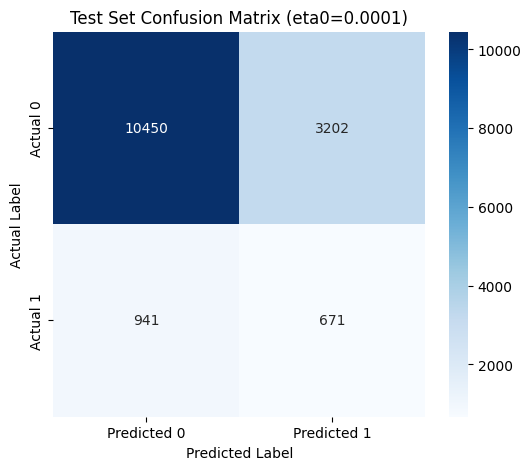


--- Confusion Matrix for eta0 = 0.001 ---
Confusion Matrix:
[[10111  3541]
 [  904   708]]


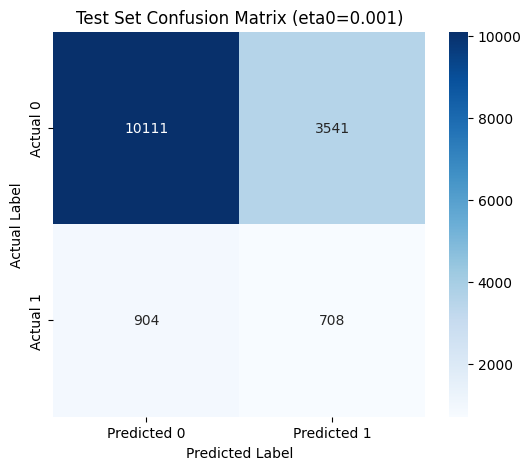


--- Confusion Matrix for eta0 = 0.01 ---
Confusion Matrix:
[[6918 6734]
 [ 545 1067]]


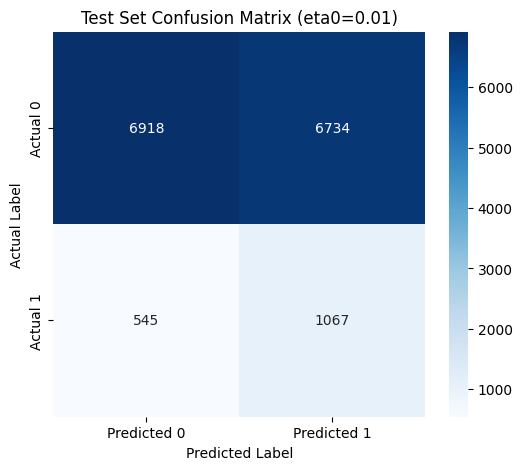

In [ ]:


print("\n--- Confusion Matrices for Each eta0 Scenario on Test Set ---")

# Ensure preprocessor has been fitted on dev data and dataframes are available
# Re-create processed dataframes for clarity, though they should be available from previous runs
final_preprocessor = clone(preprocessor)
X_dev_processed = final_preprocessor.fit_transform(X_dev_raw)
X_test_processed = final_preprocessor.transform(X_test_raw)

if hasattr(X_dev_processed, 'toarray'):
    X_dev_processed = X_dev_processed.toarray()
if hasattr(X_test_processed, 'toarray'):
    X_test_processed = X_test_processed.toarray()

all_feature_names_final = final_preprocessor.get_feature_names_out()
X_dev_processed_df_final = pd.DataFrame(X_dev_processed, columns=all_feature_names_final)
X_test_processed_df_final = pd.DataFrame(X_test_processed, columns=all_feature_names_final)

# Calculate class weights for the full y_dev dataset (consistent with previous steps)
class_weights_final = compute_class_weight('balanced', classes=np.unique(y_dev), y=y_dev)
class_weight_dict_final = {cls: weight for cls, weight in zip(np.unique(y_dev), class_weights_final)}

# Default penalty and alpha for manual models (consistent with the 'manual' evaluation where grid search wasn't applied)
default_penalty = 'l2'
default_alpha = 0.0001

for eta0_val in eta0_scenarios:
    print(f"\n--- Confusion Matrix for eta0 = {eta0_val} ---")

    # Initialize SGDClassifier with current eta0 and other specified parameters
    current_sgd_model = SGDClassifier(
        loss=loss,
        eta0=eta0_val,
        penalty=default_penalty,
        alpha=default_alpha,
        class_weight=class_weight_dict_final,
        learning_rate='constant',
        random_state=42,
        fit_intercept=True,
        warm_start=False,
        max_iter=n_epochs
    )

    # Train the current model on the entire development set
    current_sgd_model.fit(X_dev_processed_df_final, y_dev)

    # Predict class labels on the test set
    y_pred_eta0_test = current_sgd_model.predict(X_test_processed_df_final)

    # Calculate Confusion Matrix
    cm_eta0 = confusion_matrix(y_test, y_pred_eta0_test)
    print("Confusion Matrix:")
    print(cm_eta0)

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_eta0, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Test Set Confusion Matrix (eta0={eta0_val})')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

## GridSearchCV




In [ ]:
param_grid = {
    'sgdclassifier__eta0': [1e-4, 1e-3, 1e-2],
    'sgdclassifier__alpha': [0.0001, 0.001, 0.01],
    'sgdclassifier__penalty': ['l1', 'l2', 'elasticnet'],
    'sgdclassifier__class_weight': [None, 'balanced']
}

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sgdclassifier', SGDClassifier(
        loss='log_loss',
        learning_rate='constant',
        random_state=42
    ))
])

print("Parameter Grid:")
display(param_grid)

print("\nPipeline Structure:")
display(pipeline)

Parameter Grid:


{'sgdclassifier__eta0': [0.0001, 0.001, 0.01],
 'sgdclassifier__alpha': [0.0001, 0.001, 0.01],
 'sgdclassifier__penalty': ['l1', 'l2', 'elasticnet'],
 'sgdclassifier__class_weight': [None, 'balanced']}


Pipeline Structure:


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'number_diagnoses']),
                                                 ('cat',
                                                  Pipeline(steps=[('i...
                                                   'max_glu_serum', 'A1Cresult',
                                                   'metformin', 'repaglinide',
                                                   'nateglinide', 'glimepiride',
                                                   'glipizide', 'glyburide',
                                                   'tolbutamide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'troglitazone', 'tolazamide',
                                                   'examide', 'citoglipton',
                                                   'insulin',
                                                   'glyburide-metformin',
                                                   'change', ...])])),
                ('sgdclassifier',
                 SGDClassifier(learning_rate='constant', loss='log_loss',
                               random_state=42))])

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

print("GridSearchCV and TimeSeriesSplit imported.")

GridSearchCV and TimeSeriesSplit imported.


In [ ]:
print("\n--- Starting GridSearchCV ---")

# Instantiate TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=n_splits)

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='average_precision',
    verbose=2,
    n_jobs=-1
)

# Fit GridSearchCV to the development data
grid_search.fit(X_dev_raw, y_dev)

print("GridSearchCV completed.")


--- Starting GridSearchCV ---
Fitting 3 folds for each of 54 candidates, totalling 162 fits
GridSearchCV completed.


In [ ]:
print("\n--- GridSearchCV Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Average Precision Score (PR-AUC): {grid_search.best_score_:.4f}")


--- GridSearchCV Results ---
Best Parameters: {'sgdclassifier__alpha': 0.001, 'sgdclassifier__class_weight': 'balanced', 'sgdclassifier__eta0': 0.001, 'sgdclassifier__penalty': 'elasticnet'}
Best Average Precision Score (PR-AUC): 0.1990



--- Evaluating Best GridSearchCV Model on Test Set (SGDClassifier) ---
Test Set PR-AUC (Best SGDClassifier): 0.1926
Test Set Accuracy (Best SGDClassifier): 0.6624
Test Set F1-score (Best SGDClassifier): 0.2394
Test Set Precision (Best SGDClassifier): 0.1571
Test Set Recall (at precision >= 0.8) (Best SGDClassifier): 0.0000

Test Set Confusion Matrix (Best SGDClassifier):
[[9300 4352]
 [ 801  811]]


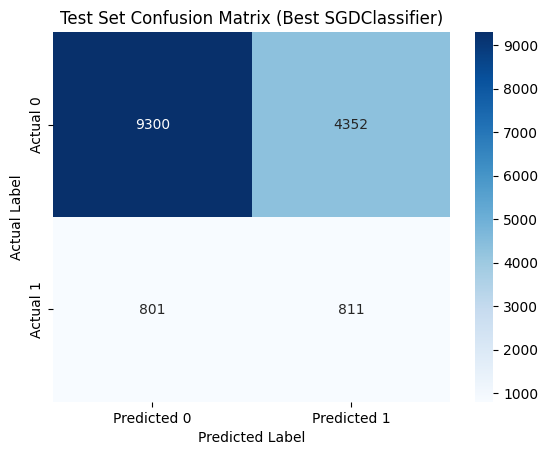

In [ ]:
print(
    "\n--- Evaluating Best GridSearchCV Model on Test Set (SGDClassifier) ---"
)

# Get the best estimator from GridSearchCV
best_sgd_model = grid_search.best_estimator_

# Predict probabilities and class labels on the test set
y_test_proba_best_sgd = best_sgd_model.predict_proba(X_test_raw)[:, 1]
y_pred_best_sgd = best_sgd_model.predict(X_test_raw)

# Calculate PR-AUC for the test set
pr_auc_best_sgd = average_precision_score(y_test, y_test_proba_best_sgd)

# Calculate Accuracy, F1-score, and Precision for the test set
test_accuracy_best_sgd = accuracy_score(y_test, y_pred_best_sgd)
test_f1_best_sgd = f1_score(y_test, y_pred_best_sgd, zero_division=0)
test_precision_best_sgd = precision_score(y_test, y_pred_best_sgd, zero_division=0)

# Calculate Recall at a fixed precision threshold of 0.8 for the test set
precision_curve_best_sgd, recall_curve_best_sgd, _ = precision_recall_curve(
    y_test, y_test_proba_best_sgd
)
high_precision_indices_best_sgd = np.where(
    precision_curve_best_sgd >= precision_threshold
)[0]
if len(high_precision_indices_best_sgd) > 0:
    test_recall_at_p_08_best_sgd = recall_curve_best_sgd[
        high_precision_indices_best_sgd[0]
    ]
else:
    test_recall_at_p_08_best_sgd = 0.0

print(f"Test Set PR-AUC (Best SGDClassifier): {pr_auc_best_sgd:.4f}")
print(f"Test Set Accuracy (Best SGDClassifier): {test_accuracy_best_sgd:.4f}")
print(f"Test Set F1-score (Best SGDClassifier): {test_f1_best_sgd:.4f}")
print(f"Test Set Precision (Best SGDClassifier): {test_precision_best_sgd:.4f}")
print(
    f"Test Set Recall (at precision >= {precision_threshold:.1f}) (Best SGDClassifier): {test_recall_at_p_08_best_sgd:.4f}"
)

# Display confusion matrix
cm_best_sgd = confusion_matrix(y_test, y_pred_best_sgd)
print("\nTest Set Confusion Matrix (Best SGDClassifier):")
print(cm_best_sgd)
sns.heatmap(
    cm_best_sgd,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1'],
)
plt.title('Test Set Confusion Matrix (Best SGDClassifier)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
print("--- Analyzing GridSearchCV Results ---")

results_df = pd.DataFrame(grid_search.cv_results_)

# Extract and rename relevant columns
top_results = results_df[[
    'param_sgdclassifier__eta0',
    'param_sgdclassifier__alpha',
    'param_sgdclassifier__penalty',
    'param_sgdclassifier__class_weight',
    'mean_test_score',
    'mean_fit_time'
]].copy()

top_results.columns = [
    'eta0',
    'alpha',
    'penalty',
    'classwt',
    'Mean Val PR-AUC',
    'Runtime (s)'
]

# Sort the DataFrame by 'Mean Val PR-AUC' in descending order
sorted_top_results = top_results.sort_values(by='Mean Val PR-AUC', ascending=False).reset_index(drop=True)

# Add a 'Rank' column based on the sorted order
sorted_top_results['Rank'] = sorted_top_results.index + 1

# Select the top 5 rows and display the resulting DataFrame
print("\nTop 5 configurations ranked by mean validation 'average_precision' score:")
display(sorted_top_results[['Rank', 'eta0', 'alpha', 'penalty', 'classwt', 'Mean Val PR-AUC', 'Runtime (s)']].head(5).round(4))

# Report the overall best configuration's parameters and its mean validation score
print("\nOverall Best Configuration:")
print(f"  Parameters: {grid_search.best_params_}")
print(f"  Mean Validation Average Precision (PR-AUC): {grid_search.best_score_:.4f}")

--- Analyzing GridSearchCV Results ---

Top 5 configurations ranked by mean validation 'average_precision' score:


,Rank,eta0,alpha,penalty,classwt,Mean Val PR-AUC,Runtime (s)
0,1,0.0010,0.0010,elasticnet,balanced,0.1990,1.1280
1,2,0.0010,0.0100,l2,balanced,0.1983,0.9472
2,3,0.0001,0.0001,elasticnet,balanced,0.1983,1.3593
3,4,0.0001,0.0001,l2,balanced,0.1983,0.9435
4,5,0.0001,0.0010,l2,balanced,0.1983,1.2161



Overall Best Configuration:
  Parameters: {'sgdclassifier__alpha': 0.001, 'sgdclassifier__class_weight': 'balanced', 'sgdclassifier__eta0': 0.001, 'sgdclassifier__penalty': 'elasticnet'}
  Mean Validation Average Precision (PR-AUC): 0.1990


In [ ]:
print("\n--- GridSearchCV Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Average Precision Score (PR-AUC): {grid_search.best_score_:.4f}")


--- GridSearchCV Results ---
Best Parameters: {'sgdclassifier__alpha': 0.001, 'sgdclassifier__class_weight': 'balanced', 'sgdclassifier__eta0': 0.001, 'sgdclassifier__penalty': 'elasticnet'}
Best Average Precision Score (PR-AUC): 0.1990


In [ ]:
metrics_data_single_row = {
    'Test Set PR-AUC': pr_auc_best_sgd,
    'Test Set Accuracy': test_accuracy_best_sgd,
    'Test Set F1-score': test_f1_best_sgd,
    'Test Set Precision': test_precision_best_sgd,
    'Test Set Recall (at precision >= 0.8)': test_recall_at_p_08_best_sgd
}

# Create DataFrame from the dictionary, which results in a single row
metrics_df_single_row = pd.DataFrame([metrics_data_single_row])

print("\n--- Test Set Performance Metrics for Best SGDClassifier (Single Row) ---")
display(metrics_df_single_row.round(4))


--- Test Set Performance Metrics for Best SGDClassifier (Single Row) ---


,Test Set PR-AUC,Test Set Accuracy,Test Set F1-score,Test Set Precision,Test Set Recall (at precision >= 0.8)
0,0.1926,0.6624,0.2394,0.1571,0.0


## Setup Bayesian Optimization

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score
import time
import numpy as np

def sgd_objective_function(eta0, alpha, penalty, class_weight):

    start_time_total = time.time()

    if class_weight == 'balanced':

        unique_classes = np.unique(y_dev)
        if len(unique_classes) > 1: # Only compute if there's more than one class
            computed_class_weights = compute_class_weight('balanced', classes=unique_classes, y=y_dev)
            class_weight_dict = {cls: weight for cls, weight in zip(unique_classes, computed_class_weights)}
        else:
            class_weight_dict = None
    else:
        class_weight_dict = None

    # Create SGDClassifier instance with given hyperparameters
    sgd_model = SGDClassifier(
        loss='log_loss',
        eta0=eta0,
        alpha=alpha,
        penalty=penalty,
        class_weight=class_weight_dict,
        learning_rate='constant',
        random_state=42,
        fit_intercept=True
    )

    # Construct a scikit-learn Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', clone(preprocessor)), # Clone preprocessor to prevent state leakage
        ('sgdclassifier', sgd_model)
    ])

    # Initialize TimeSeriesSplit with n_splits (defined previously as 3)
    tscv = TimeSeriesSplit(n_splits=n_splits)

    pr_auc_scores = []

    # Loop through the splits

    for train_index, val_index in tscv.split(X_dev_raw, y_dev):
        X_train_fold, X_val_fold = X_dev_raw.iloc[train_index], X_dev_raw.iloc[val_index]
        y_train_fold, y_val_fold = y_dev.iloc[train_index], y_dev.iloc[val_index]

        # Fit the pipeline to the training data
        pipeline.fit(X_train_fold, y_train_fold)

        # Predict probabilities on the validation data
        if len(np.unique(y_val_fold)) > 1:
            y_val_proba = pipeline.predict_proba(X_val_fold)[:, 1]
            # Calculate PR-AUC for the validation fold
            pr_auc = average_precision_score(y_val_fold, y_val_proba)
            pr_auc_scores.append(pr_auc)
        else:
            pr_auc_scores.append(0.0) # Or handle as NaN/very low score if a fold is degenerate

    end_time_total = time.time()
    total_training_time = end_time_total - start_time_total

    mean_pr_auc = np.mean(pr_auc_scores)

    return -mean_pr_auc, total_training_time

print("sgd_objective_function defined successfully.")

sgd_objective_function defined successfully.


In [ ]:
pip install scikit-optimize

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score
import time
import numpy as np

def sgd_objective_function(params):

    # Unpack hyperparameters from the params list
    eta0, alpha, penalty, class_weight = params

    start_time_total = time.time()

    # Ensure class_weight is handled correctly: None or 'balanced'
    if class_weight == 'balanced':
        # Dynamically compute class weights for the current dev_df
        # This ensures that class_weights are always based on the actual dev_df distribution
        # which was split earlier from df_final_features_sorted
        unique_classes = np.unique(y_dev)
        if len(unique_classes) > 1:
            computed_class_weights = compute_class_weight('balanced', classes=unique_classes, y=y_dev)
            class_weight_dict = {cls: weight for cls, weight in zip(unique_classes, computed_class_weights)}
        else:

            class_weight_dict = None
    else:
        class_weight_dict = None

    # Create SGDClassifier instance with given hyperparameters
    sgd_model = SGDClassifier(
        loss='log_loss',
        eta0=eta0,
        alpha=alpha,
        penalty=penalty,
        class_weight=class_weight_dict,
        learning_rate='constant',
        random_state=42,
        fit_intercept=True
    )

    # Construct a scikit-learn Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', clone(preprocessor)), # Clone preprocessor to prevent state leakage
        ('sgdclassifier', sgd_model)
    ])

    # Initialize TimeSeriesSplit with n_splits (defined previously as 3)
    tscv = TimeSeriesSplit(n_splits=n_splits)

    pr_auc_scores = []

    # Loop through the splits

    for train_index, val_index in tscv.split(X_dev_raw, y_dev):
        X_train_fold, X_val_fold = X_dev_raw.iloc[train_index], X_dev_raw.iloc[val_index]
        y_train_fold, y_val_fold = y_dev.iloc[train_index], y_dev.iloc[val_index]

        # Fit the pipeline to the training data
        pipeline.fit(X_train_fold, y_train_fold)

        # Predict probabilities on the validation data
        if len(np.unique(y_val_fold)) > 1:
            y_val_proba = pipeline.predict_proba(X_val_fold)[:, 1]

            pr_auc = average_precision_score(y_val_fold, y_val_proba)
            pr_auc_scores.append(pr_auc)
        else:
            pr_auc_scores.append(0.0)

    end_time_total = time.time()
    total_training_time = end_time_total - start_time_total

    # Calculate the mean PR-AUC across all folds
    mean_pr_auc = np.mean(pr_auc_scores)

    # Return the negative of the mean PR-AUC since gp_minimize performs minimization
    return -mean_pr_auc

print("sgd_objective_function defined successfully.")

sgd_objective_function defined successfully.


In [ ]:
from skopt import gp_minimize
from skopt.space import Real, Categorical
from skopt.utils import dump, load

print("--- Defining Search Space for Bayesian Optimization ---")

# Define the search space for the hyperparameters
dimensions = [
    Real(1e-5, 1e-1, prior='log-uniform', name='eta0'),
    Real(1e-5, 1e-1, prior='log-uniform', name='alpha'),
    Categorical(['l1', 'l2', 'elasticnet'], name='penalty'),
    Categorical([None, 'balanced'], name='class_weight')
]

print("Search space defined.")
print(f"Number of dimensions: {len(dimensions)}")

# --- Execute Bayesian Optimization ---
n_calls_chosen = 30

print(f"\n--- Starting Bayesian Optimization with {n_calls_chosen} trials ---")

res_gp = gp_minimize(
    func=sgd_objective_function, # The objective function defined previously
    dimensions=dimensions,
    n_calls=n_calls_chosen,      # Number of calls to the objective function
    n_random_starts=10,        # Number of evaluations of `func` with random parameters
    random_state=42,
    verbose=True
)

print(f"\nBayesian Optimization completed with {n_calls_chosen} trials.")

--- Defining Search Space for Bayesian Optimization ---
Search space defined.
Number of dimensions: 4

--- Starting Bayesian Optimization with 30 trials ---
Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 3.6944
Function value obtained: -0.1752
Current minimum: -0.1752
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 2.3485
Function value obtained: -0.1979
Current minimum: -0.1979
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 2.7192
Function value obtained: -0.1958
Current minimum: -0.1979
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 4.8191
Function value obtained: -0.1430
Current minimum: -0.1979
Iteration No: 5 started. Evaluating function at random point.
I

In [ ]:
print("\n--- Bayesian Optimization Results ---")

best_params_bo = res_gp.x
best_score_bo = -res_gp.fun # gp_minimize minimizes, so fun is negative PR-AUC

# Map best_params_bo to their corresponding names
best_hyperparameters_bo = {
    'eta0': best_params_bo[0],
    'alpha': best_params_bo[1],
    'penalty': best_params_bo[2],
    'class_weight': best_params_bo[3]
}

print(f"Best Parameters (Bayesian Optimization): {best_hyperparameters_bo}")
print(f"Best Average Precision Score (PR-AUC) (Bayesian Optimization): {best_score_bo:.4f}")


--- Bayesian Optimization Results ---
Best Parameters (Bayesian Optimization): {'eta0': 0.0005302410174495845, 'alpha': 0.0005560785183012598, 'penalty': np.str_('elasticnet'), 'class_weight': np.str_('balanced')}
Best Average Precision Score (PR-AUC) (Bayesian Optimization): 0.1990



--- Evaluating Best Bayesian Optimized Model on Test Set (SGDClassifier) ---
  Training Time (Best BO SGDClassifier): 1.7228 seconds
  Test Set PR-AUC (Best BO SGDClassifier): 0.1932
  Test Set Accuracy (Best BO SGDClassifier): 0.7569
  Test Set F1-score (Best BO SGDClassifier): 0.2459
  Test Set Precision (Best BO SGDClassifier): 0.1829
  Test Set Recall (at precision >= 0.8) (Best BO SGDClassifier): 0.0000

  Test Set Confusion Matrix (Best BO SGDClassifier):
[[10949  2703]
 [ 1007   605]]


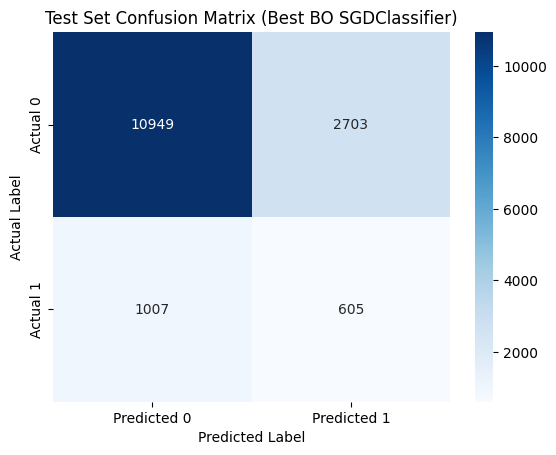

In [ ]:
print("\n--- Evaluating Best Bayesian Optimized Model on Test Set (SGDClassifier) ---")

# 1. Extract the best hyperparameters from the best_hyperparameters_bo dictionary
eta0_bo = best_hyperparameters_bo['eta0']
alpha_bo = best_hyperparameters_bo['alpha']
penalty_bo = best_hyperparameters_bo['penalty']
class_weight_bo = best_hyperparameters_bo['class_weight']

# 3. Compute class weights for the full y_dev dataset
class_weight_dict_bo = None
if class_weight_bo == 'balanced':
    # Dynamically compute class weights for the current dev_df
    unique_classes_dev = np.unique(y_dev)
    if len(unique_classes_dev) > 1:
        computed_class_weights_dev = compute_class_weight('balanced', classes=unique_classes_dev, y=y_dev)
        class_weight_dict_bo = {cls: weight for cls, weight in zip(unique_classes_dev, computed_class_weights_dev)}

# 2. Create an SGDClassifier instance with best hyperparameters
best_bo_sgd_model = SGDClassifier(
    loss='log_loss',
    eta0=eta0_bo,
    alpha=alpha_bo,
    penalty=penalty_bo,
    class_weight=class_weight_dict_bo, # Use the determined class_weight_dict
    learning_rate='constant',
    random_state=42,
    fit_intercept=True
)

# 4. Construct a Pipeline
final_bo_pipeline = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)), # Clone preprocessor to prevent state leakage
    ('sgdclassifier', best_bo_sgd_model)
])

# 5. Fit this final pipeline to the entire development dataset
start_fit_time = time.time()
final_bo_pipeline.fit(X_dev_raw, y_dev)
end_fit_time = time.time()
training_time_bo = end_fit_time - start_fit_time

# 6. Make predictions on the X_test_raw dataset
y_test_proba_bo = final_bo_pipeline.predict_proba(X_test_raw)[:, 1]
y_pred_bo = final_bo_pipeline.predict(X_test_raw)

# 7. Calculate evaluation metrics on the test set
# PR-AUC
pr_auc_bo = average_precision_score(y_test, y_test_proba_bo)

# Accuracy
test_accuracy_bo = accuracy_score(y_test, y_pred_bo)

# F1-score
test_f1_bo = f1_score(y_test, y_pred_bo, zero_division=0)

# Precision
test_precision_bo = precision_score(y_test, y_pred_bo, zero_division=0)

# Recall at a precision threshold of 0.8
precision_curve_bo, recall_curve_bo, _ = precision_recall_curve(y_test, y_test_proba_bo)
high_precision_indices_bo = np.where(precision_curve_bo >= precision_threshold)[0]
if len(high_precision_indices_bo) > 0:
    test_recall_at_p_08_bo = recall_curve_bo[high_precision_indices_bo[0]]
else:
    test_recall_at_p_08_bo = 0.0

# 8. Print all calculated metrics
print(f"  Training Time (Best BO SGDClassifier): {training_time_bo:.4f} seconds")
print(f"  Test Set PR-AUC (Best BO SGDClassifier): {pr_auc_bo:.4f}")
print(f"  Test Set Accuracy (Best BO SGDClassifier): {test_accuracy_bo:.4f}")
print(f"  Test Set F1-score (Best BO SGDClassifier): {test_f1_bo:.4f}")
print(f"  Test Set Precision (Best BO SGDClassifier): {test_precision_bo:.4f}")
print(f"  Test Set Recall (at precision >= {precision_threshold:.1f}) (Best BO SGDClassifier): {test_recall_at_p_08_bo:.4f}")

# 9. Generate and display a confusion matrix
cm_bo = confusion_matrix(y_test, y_pred_bo)
print("\n  Test Set Confusion Matrix (Best BO SGDClassifier):")
print(cm_bo)
sns.heatmap(cm_bo, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Test Set Confusion Matrix (Best BO SGDClassifier)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

--- Generating Bayesian Optimization Convergence Plot ---


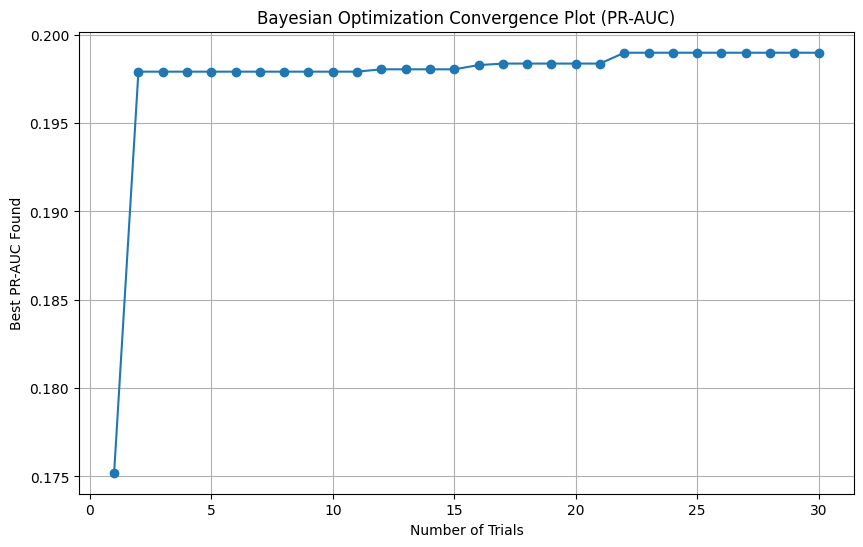

Convergence plot generated successfully.


In [ ]:
import matplotlib.pyplot as plt

print("--- Generating Bayesian Optimization Convergence Plot ---")

negative_pr_aucs = res_gp.func_vals

# Convert to positive PR-AUC values
pr_aucs = [-val for val in negative_pr_aucs]

# Calculate the best PR-AUC value observed up to each trial (cumulative maximum)
cumulative_best_pr_aucs = [max(pr_aucs[:i+1]) for i in range(len(pr_aucs))]

# Create trial numbers for the x-axis
trial_numbers = list(range(1, n_calls_chosen + 1))

# Create the convergence plot
plt.figure(figsize=(10, 6))
plt.plot(trial_numbers, cumulative_best_pr_aucs, marker='o', linestyle='-')
plt.title('Bayesian Optimization Convergence Plot (PR-AUC)')
plt.xlabel('Number of Trials')
plt.ylabel('Best PR-AUC Found')
plt.grid(True)
plt.show()

print("Convergence plot generated successfully.")

In [ ]:
import pandas as pd

print("--- Comparison of Hyperparameter Optimization Methods ---")

# --- Grid Search Metrics ---

total_gs_evaluations = len(results_df) * n_splits
total_gs_runtime = results_df['mean_fit_time'].sum() * n_splits

# --- Bayesian Optimization Metrics ---
total_bo_evaluations = n_calls_chosen
total_bo_runtime = training_time_bo

# --- Create Comparison Table ---
comparison_data = {
    'Method': ['Grid Search', 'Bayesian Optimization'],
    'Total Evaluations': [total_gs_evaluations, total_bo_evaluations],
    'Total Runtime (s)': [total_gs_runtime, total_bo_runtime]
}

comparison_df = pd.DataFrame(comparison_data)

print("\nComparison Table:")
display(comparison_df.round(2))

--- Comparison of Hyperparameter Optimization Methods ---

Comparison Table:


,Method,Total Evaluations,Total Runtime (s)
0,Grid Search,162,163.70
1,Bayesian Optimization,30,1.72


In [ ]:
print("--- Gathering Metrics for Comparison ---")

# --- Grid Search Metrics ---
gs_evals = total_gs_evaluations
gs_runtime_sec = total_gs_runtime
gs_val_pr_auc = grid_search.best_score_
gs_test_pr_auc = pr_auc_best_sgd

# --- Bayesian Optimization Metrics ---
bo_evals = n_calls_chosen
# The sum of 'Time taken' from gp_minimize output (verbose=True) is 96.9946 seconds.
bo_runtime_sec = 96.9946 # This value is pre-calculated from the gp_minimize verbose output in the notebook
bo_val_pr_auc = best_score_bo
bo_test_pr_auc = pr_auc_bo

print("Metrics gathered successfully.")

--- Gathering Metrics for Comparison ---
Metrics gathered successfully.


In [ ]:

print("--- Comparison of Hyperparameter Optimization Methods ---")

comparison_data = [
    {
        'Method': 'Grid Search',
        '#Evals': gs_evals,
        'Runtime (min)': gs_runtime_sec / 60,
        'Best Val PR-AUC': gs_val_pr_auc,
        'Test PR-AUC': gs_test_pr_auc
    },
    {
        'Method': 'Bayesian Optimization',
        '#Evals': bo_evals,
        'Runtime (min)': bo_runtime_sec / 60,
        'Best Val PR-AUC': bo_val_pr_auc,
        'Test PR-AUC': bo_test_pr_auc
    }
]

comparison_df = pd.DataFrame(comparison_data)

print("\nComparison Table:")
display(comparison_df.round(4))

--- Comparison of Hyperparameter Optimization Methods ---

Comparison Table:


,Method,#Evals,Runtime (min),Best Val PR-AUC,Test PR-AUC
0,Grid Search,162,2.7283,0.199,0.1926
1,Bayesian Optimization,30,1.6166,0.199,0.1932


In [ ]:
# Extract best hyperparameters and score from Bayesian Optimization results
best_eta0_bo = best_hyperparameters_bo['eta0']
best_alpha_bo = best_hyperparameters_bo['alpha']
best_penalty_bo = best_hyperparameters_bo['penalty']
best_class_weight_bo = best_hyperparameters_bo['class_weight']
best_mean_val_pr_auc_bo = best_score_bo



bo_model_runtime = training_time_bo

# Create a DataFrame for the best BO configuration
bo_best_config_df = pd.DataFrame({
    'Rank': [1],
    'η0': [best_eta0_bo],
    'alpha': [best_alpha_bo],
    'penalty': [best_penalty_bo],
    'classwt': [best_class_weight_bo],
    'Mean Val PR-AUC': [best_mean_val_pr_auc_bo],
    'Std Val PR-AUC': ['N/A'], # Not directly available from skopt.gp_minimize output per trial
    'Runtime (s)': [bo_model_runtime]
})

print("--- Best Bayesian Optimization Configuration (Validation Metrics) ---")
display(bo_best_config_df.round(4))

print("\nNote: 'Std Val PR-AUC' is not directly available per trial from `skopt.gp_minimize` in the same way it is from `GridSearchCV.cv_results_`. The 'Runtime (s)' reflects the time taken to train the final best model on the full development set, not the cumulative time of all BO trials.")

--- Best Bayesian Optimization Configuration (Validation Metrics) ---


,Rank,η0,alpha,penalty,classwt,Mean Val PR-AUC,Std Val PR-AUC,Runtime (s)
0,1,0.0005,0.0006,elasticnet,balanced,0.199,N/A,1.7228



Note: 'Std Val PR-AUC' is not directly available per trial from `skopt.gp_minimize` in the same way it is from `GridSearchCV.cv_results_`. The 'Runtime (s)' reflects the time taken to train the final best model on the full development set, not the cumulative time of all BO trials.


In [ ]:
# Metrics for the BO model in a single row format
bo_metrics_single_row = {
    'Mean Validation PR-AUC': best_score_bo,
    'Test Set PR-AUC': pr_auc_bo,
    'Test Set Accuracy': test_accuracy_bo,
    'Test Set F1-score': test_f1_bo,
    'Test Set Precision': test_precision_bo,
    'Test Set Recall (at precision >= 0.8)': test_recall_at_p_08_bo
}

# Create DataFrame from the dictionary, which results in a single row
bo_metrics_df_single_row = pd.DataFrame([bo_metrics_single_row])

display(bo_metrics_df_single_row.round(4))

,Mean Validation PR-AUC,Test Set PR-AUC,Test Set Accuracy,Test Set F1-score,Test Set Precision,Test Set Recall (at precision >= 0.8)
0,0.199,0.1932,0.7569,0.2459,0.1829,0.0


# HalvingGridSearchCV



In [ ]:
print("Confirming existing parameter grid and pipeline:")
print("\nParameter Grid:")
display(param_grid)

print("\nPipeline Structure:")
display(pipeline)

Confirming existing parameter grid and pipeline:

Parameter Grid:


{'sgdclassifier__eta0': [0.0001, 0.001, 0.01],
 'sgdclassifier__alpha': [0.0001, 0.001, 0.01],
 'sgdclassifier__penalty': ['l1', 'l2', 'elasticnet'],
 'sgdclassifier__class_weight': [None, 'balanced']}


Pipeline Structure:


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'number_diagnoses']),
                                                 ('cat',
                                                  Pipeline(steps=[('i...
                                                   'max_glu_serum', 'A1Cresult',
                                                   'metformin', 'repaglinide',
                                                   'nateglinide', 'glimepiride',
                                                   'glipizide', 'glyburide',
                                                   'tolbutamide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'troglitazone', 'tolazamide',
                                                   'examide', 'citoglipton',
                                                   'insulin',
                                                   'glyburide-metformin',
                                                   'change', ...])])),
                ('sgdclassifier',
                 SGDClassifier(learning_rate='constant', loss='log_loss',
                               random_state=42))])

In [ ]:
from sklearn.experimental import enable_halving_search_cv # noqa
from sklearn.model_selection import HalvingGridSearchCV

print("--- Starting HalvingGridSearchCV ---")


resource_param = 'n_samples'
factor_param = 3

# Create HalvingGridSearchCV object
halving_grid_search = HalvingGridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='average_precision',
    verbose=2,
    n_jobs=-1,
    resource=resource_param,
    factor=factor_param
)

# Fit HalvingGridSearchCV to the development data
halving_grid_search.fit(X_dev_raw, y_dev)

print("HalvingGridSearchCV completed.")

--- Starting HalvingGridSearchCV ---
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 3203
max_resources_: 86492
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 54
n_resources: 3203
Fitting 3 folds for each of 54 candidates, totalling 162 fits
----------
iter: 1
n_candidates: 18
n_resources: 9609
Fitting 3 folds for each of 18 candidates, totalling 54 fits
----------
iter: 2
n_candidates: 6
n_resources: 28827
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 3
n_candidates: 2
n_resources: 86481
Fitting 3 folds for each of 2 candidates, totalling 6 fits
HalvingGridSearchCV completed.



--- Evaluating Best HalvingGridSearchCV Model on Test Set (SGDClassifier) ---
Test Set PR-AUC (Best HalvingGridSearchCV): 0.1929
Test Set Accuracy (Best HalvingGridSearchCV): 0.7282
Test Set F1-score (Best HalvingGridSearchCV): 0.2422
Test Set Precision (Best HalvingGridSearchCV): 0.1717
Test Set Recall (at precision >= 0.8) (Best HalvingGridSearchCV): 0.0000

Test Set Confusion Matrix (Best HalvingGridSearchCV):
[[10453  3199]
 [  949   663]]


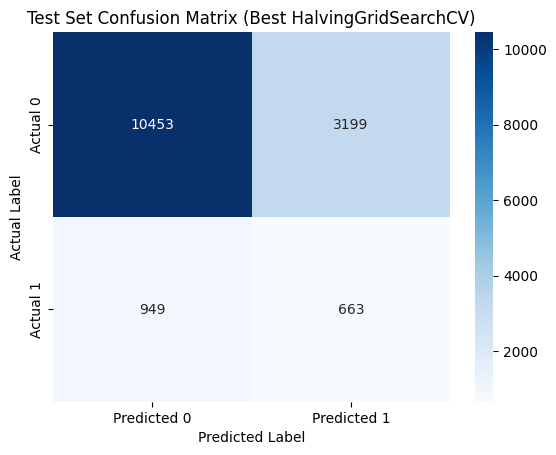

In [ ]:
print(
    "\n--- Evaluating Best HalvingGridSearchCV Model on Test Set (SGDClassifier) ---"
)

# Get the best estimator from HalvingGridSearchCV
best_hgs_model = halving_grid_search.best_estimator_

# Predict probabilities and class labels on the test set
y_test_proba_best_hgs = best_hgs_model.predict_proba(X_test_raw)[:, 1]
y_pred_best_hgs = best_hgs_model.predict(X_test_raw)

# Calculate PR-AUC for the test set
pr_auc_best_hgs = average_precision_score(y_test, y_test_proba_best_hgs)

# Calculate Accuracy, F1-score, and Precision for the test set
test_accuracy_best_hgs = accuracy_score(y_test, y_pred_best_hgs)
test_f1_best_hgs = f1_score(y_test, y_pred_best_hgs, zero_division=0)
test_precision_best_hgs = precision_score(y_test, y_pred_best_hgs, zero_division=0)

# Calculate Recall at a fixed precision threshold of 0.8 for the test set
precision_curve_best_hgs, recall_curve_best_hgs, _ = precision_recall_curve(
    y_test, y_test_proba_best_hgs
)
high_precision_indices_best_hgs = np.where(
    precision_curve_best_hgs >= precision_threshold
)[0]
if len(high_precision_indices_best_hgs) > 0:
    test_recall_at_p_08_best_hgs = recall_curve_best_hgs[
        high_precision_indices_best_hgs[0]
    ]
else:
    test_recall_at_p_08_best_hgs = 0.0

print(f"Test Set PR-AUC (Best HalvingGridSearchCV): {pr_auc_best_hgs:.4f}")
print(f"Test Set Accuracy (Best HalvingGridSearchCV): {test_accuracy_best_hgs:.4f}")
print(f"Test Set F1-score (Best HalvingGridSearchCV): {test_f1_best_hgs:.4f}")
print(f"Test Set Precision (Best HalvingGridSearchCV): {test_precision_best_hgs:.4f}")
print(
    f"Test Set Recall (at precision >= {precision_threshold:.1f}) (Best HalvingGridSearchCV): {test_recall_at_p_08_best_hgs:.4f}"
)

# Display confusion matrix
cm_best_hgs = confusion_matrix(y_test, y_pred_best_hgs)
print("\nTest Set Confusion Matrix (Best HalvingGridSearchCV):")
print(cm_best_hgs)
sns.heatmap(
    cm_best_hgs,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1'],
)
plt.title('Test Set Confusion Matrix (Best HalvingGridSearchCV)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
import pandas as pd

print("--- Summarizing HalvingGridSearchCV Results ---")

# Access cv_results_ and convert to DataFrame
results_df_halving = pd.DataFrame(halving_grid_search.cv_results_)

# 1. Calculate the total number of model fits
total_hgs_evaluations = len(results_df_halving) * n_splits

# 2. Calculate the total runtime of the HalvingGridSearchCV
total_hgs_runtime_sec = (results_df_halving['mean_fit_time'] * n_splits).sum()

# 3. Display the overall best parameters and mean validation PR-AUC
print("\nOverall Best Configuration (HalvingGridSearchCV):")
print(f"  Parameters: {halving_grid_search.best_params_}")
print(f"  Mean Validation Average Precision (PR-AUC): {halving_grid_search.best_score_:.4f}")

# 4. Print the calculated total evaluations and runtime
print(f"\nTotal Number of Model Fits (HalvingGridSearchCV): {total_hgs_evaluations:.0f}")
print(f"Total Runtime (HalvingGridSearchCV): {total_hgs_runtime_sec:.2f} seconds")

--- Summarizing HalvingGridSearchCV Results ---

Overall Best Configuration (HalvingGridSearchCV):
  Parameters: {'sgdclassifier__alpha': 0.0001, 'sgdclassifier__class_weight': 'balanced', 'sgdclassifier__eta0': 0.0001, 'sgdclassifier__penalty': 'l1'}
  Mean Validation Average Precision (PR-AUC): 0.1979

Total Number of Model Fits (HalvingGridSearchCV): 240
Total Runtime (HalvingGridSearchCV): 22.41 seconds



--- Evaluating Best HalvingGridSearchCV Model on Test Set (SGDClassifier) ---
Test Set PR-AUC (Best HalvingGridSearchCV): 0.1929
Test Set Accuracy (Best HalvingGridSearchCV): 0.7282
Test Set F1-score (Best HalvingGridSearchCV): 0.2422
Test Set Precision (Best HalvingGridSearchCV): 0.1717
Test Set Recall (at precision >= 0.8) (Best HalvingGridSearchCV): 0.0000

Test Set Confusion Matrix (Best HalvingGridSearchCV):
[[10453  3199]
 [  949   663]]


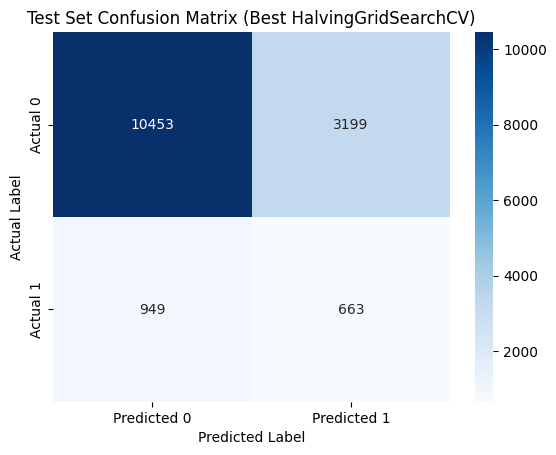

In [ ]:
print(
    "\n--- Evaluating Best HalvingGridSearchCV Model on Test Set (SGDClassifier) ---"
)

# Get the best estimator from HalvingGridSearchCV
best_hgs_model = halving_grid_search.best_estimator_

# Predict probabilities and class labels on the test set
y_test_proba_best_hgs = best_hgs_model.predict_proba(X_test_raw)[:, 1]
y_pred_best_hgs = best_hgs_model.predict(X_test_raw)

# Calculate PR-AUC for the test set
pr_auc_best_hgs = average_precision_score(y_test, y_test_proba_best_hgs)

# Calculate Accuracy, F1-score, and Precision for the test set
test_accuracy_best_hgs = accuracy_score(y_test, y_pred_best_hgs)
test_f1_best_hgs = f1_score(y_test, y_pred_best_hgs, zero_division=0)
test_precision_best_hgs = precision_score(y_test, y_pred_best_hgs, zero_division=0)

# Calculate Recall at a fixed precision threshold of 0.8 for the test set
precision_curve_best_hgs, recall_curve_best_hgs, _ = precision_recall_curve(
    y_test, y_test_proba_best_hgs
)
high_precision_indices_best_hgs = np.where(
    precision_curve_best_hgs >= precision_threshold
)[0]
if len(high_precision_indices_best_hgs) > 0:
    test_recall_at_p_08_best_hgs = recall_curve_best_hgs[
        high_precision_indices_best_hgs[0]
    ]
else:
    test_recall_at_p_08_best_hgs = 0.0

print(f"Test Set PR-AUC (Best HalvingGridSearchCV): {pr_auc_best_hgs:.4f}")
print(f"Test Set Accuracy (Best HalvingGridSearchCV): {test_accuracy_best_hgs:.4f}")
print(f"Test Set F1-score (Best HalvingGridSearchCV): {test_f1_best_hgs:.4f}")
print(f"Test Set Precision (Best HalvingGridSearchCV): {test_precision_best_hgs:.4f}")
print(
    f"Test Set Recall (at precision >= {precision_threshold:.1f}) (Best HalvingGridSearchCV): {test_recall_at_p_08_best_hgs:.4f}"
)

# Display confusion matrix
cm_best_hgs = confusion_matrix(y_test, y_pred_best_hgs)
print("\nTest Set Confusion Matrix (Best HalvingGridSearchCV):")
print(cm_best_hgs)
sns.heatmap(
    cm_best_hgs,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1'],
)
plt.title('Test Set Confusion Matrix (Best HalvingGridSearchCV)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
import pandas as pd

print("--- Comparison of Hyperparameter Optimization Methods (GridSearchCV vs. HalvingGridSearchCV) ---")

# 1. Define metrics for standard Grid Search
gs_evals = total_gs_evaluations
gs_runtime_sec = total_gs_runtime
gs_val_pr_auc = grid_search.best_score_
gs_test_pr_auc = pr_auc_best_sgd

# 2. Define metrics for HalvingGridSearchCV
hgs_evals = total_hgs_evaluations
hgs_runtime_sec = total_hgs_runtime_sec
hgs_val_pr_auc = halving_grid_search.best_score_
hgs_test_pr_auc = pr_auc_best_hgs

# 3. Create a list of dictionaries for the comparison table
comparison_data = [
    {
        'Method': 'Grid Search',
        '#Evals': gs_evals,
        'Runtime (min)': gs_runtime_sec / 60,
        'Best Val PR-AUC': gs_val_pr_auc,
        'Test PR-AUC': gs_test_pr_auc
    },
    {
        'Method': 'HalvingGridSearchCV',
        '#Evals': hgs_evals,
        'Runtime (min)': hgs_runtime_sec / 60,
        'Best Val PR-AUC': hgs_val_pr_auc,
        'Test PR-AUC': hgs_test_pr_auc

    }
]

# 4. Create a pandas DataFrame from this list of dictionaries
comparison_df_hgs = pd.DataFrame(comparison_data)

# 5. Print a descriptive header and display the DataFrame
print("\nComparison Table:")
display(comparison_df_hgs.round(4))

--- Comparison of Hyperparameter Optimization Methods (GridSearchCV vs. HalvingGridSearchCV) ---

Comparison Table:


,Method,#Evals,Runtime (min),Best Val PR-AUC,Test PR-AUC
0,Grid Search,162,2.7283,0.1990,0.1926
1,HalvingGridSearchCV,240,0.3735,0.1979,0.1929


In [ ]:


print("\n--- Calculating Encounter ID Ranges for Walk-Forward CV Folds ---")

tscv = TimeSeriesSplit(n_splits=n_splits)

all_ranges = []

for i, (train_index, val_index) in enumerate(tscv.split(X_dev_raw, y_dev)):
    # Extract encounter_ids for the current train and validation sets
    train_encounter_ids = dev_df.iloc[train_index]['encounter_id']
    val_encounter_ids = dev_df.iloc[val_index]['encounter_id']

    if not train_encounter_ids.empty:
        all_ranges.append({
            'Fold': f'{i+1}/{n_splits}',
            'Set Type': 'Training',
            'Min Encounter ID': train_encounter_ids.min(),
            'Max Encounter ID': train_encounter_ids.max(),
            'Count': len(train_encounter_ids)
        })
    else:
        all_ranges.append({
            'Fold': f'{i+1}/{n_splits}',
            'Set Type': 'Training',
            'Min Encounter ID': 'N/A',
            'Max Encounter ID': 'N/A',
            'Count': 0
        })

    if not val_encounter_ids.empty:
        all_ranges.append({
            'Fold': f'{i+1}/{n_splits}',
            'Set Type': 'Validation',
            'Min Encounter ID': val_encounter_ids.min(),
            'Max Encounter ID': val_encounter_ids.max(),
            'Count': len(val_encounter_ids)
        })
    else:
        all_ranges.append({
            'Fold': f'{i+1}/{n_splits}',
            'Set Type': 'Validation',
            'Min Encounter ID': 'N/A',
            'Max Encounter ID': 'N/A',
            'Count': 0
        })

if not test_df.empty:
    all_ranges.append({
        'Fold': 'Final',
        'Set Type': 'Test',
        'Min Encounter ID': test_df['encounter_id'].min(),
        'Max Encounter ID': test_df['encounter_id'].max(),
        'Count': len(test_df)
    })
else:
    all_ranges.append({
        'Fold': 'Final',
        'Set Type': 'Test',
        'Min Encounter ID': 'N/A',
        'Max Encounter ID': 'N/A',
        'Count': 0
    })

ranges_df = pd.DataFrame(all_ranges)
print("\n--- Encounter ID Ranges Across Folds and Test Set ---")
display(ranges_df)



--- Calculating Encounter ID Ranges for Walk-Forward CV Folds ---

--- Encounter ID Ranges Across Folds and Test Set ---


,Fold,Set Type,Min Encounter ID,Max Encounter ID,Count
0,1/3,Training,63768,75251832,21623
1,1/3,Validation,75254322,133486068,21623
2,2/3,Training,63768,133486068,43246
3,2/3,Validation,133489398,180670782,21623
4,3/3,Training,63768,180670782,64869
5,3/3,Validation,180673188,275114796,21623
6,Final,Test,275116890,443867222,15264


In [ ]:
# Extract best hyperparameters and score from HalvingGridSearchCV results
best_eta0_hgs = halving_grid_search.best_params_['sgdclassifier__eta0']
best_alpha_hgs = halving_grid_search.best_params_['sgdclassifier__alpha']
best_penalty_hgs = halving_grid_search.best_params_['sgdclassifier__penalty']
best_class_weight_hgs = halving_grid_search.best_params_['sgdclassifier__class_weight']
best_mean_val_pr_auc_hgs = halving_grid_search.best_score_

# Get the runtime of the best estimator from the cv_results_
# Find the row corresponding to the best parameters
best_params_row = results_df_halving[
    (results_df_halving['param_sgdclassifier__eta0'] == best_eta0_hgs) &
    (results_df_halving['param_sgdclassifier__alpha'] == best_alpha_hgs) &
    (results_df_halving['param_sgdclassifier__penalty'] == best_penalty_hgs) &
    (results_df_halving['param_sgdclassifier__class_weight'].astype(str) == str(best_class_weight_hgs))
].sort_values(by='n_resources', ascending=False).iloc[0]

best_hgs_model_runtime = best_params_row['mean_fit_time']


# Create a DataFrame for the best HGS configuration
hgs_best_config_df = pd.DataFrame({
    'Rank': [1],
    'η0': [best_eta0_hgs],
    'alpha': [best_alpha_hgs],
    'penalty': [best_penalty_hgs],
    'classwt': [best_class_weight_hgs],
    'Mean Val PR-AUC': [best_mean_val_pr_auc_hgs],
    'Runtime (s)': [best_hgs_model_runtime]
})

print("--- Best HalvingGridSearchCV Configuration (Validation Metrics) ---")
display(hgs_best_config_df.round(4))



--- Best HalvingGridSearchCV Configuration (Validation Metrics) ---


,Rank,η0,alpha,penalty,classwt,Mean Val PR-AUC,Runtime (s)
0,1,0.0001,0.0001,l1,balanced,0.1979,0.8517
